**Cognitive Load Estimation Pipeline**






##Part 2: implementation



**Part 2.1: Preprocessing and Data Cleaning**

Reference:
https://colab.research.google.com/drive/1TcGrzhtlb6XdIE33l5cnedPeaPlyNrNE?usp=sharing#scrollTo=dvW88ppE1FrB



##**Import python libraries**

In [ ]:
#to access files and folders
import os
#data analysis and manipulation library
import pandas as pd
#math operations for multi-dimensional arrays and matrices
import numpy as np
#visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set() #use a specific color theme

##**Data reading**

In [ ]:
#Connect this Google Colab to your peronal Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Each file contains individual's physiologocal data

In [ ]:
#check if we can access the data
data_folder_path = '/content/drive/MyDrive/CogLoad-1Hz/'
os.listdir(data_folder_path) #list files and folders

['yljm5_sensors.csv',
 'f1gjp_sensors.csv',
 'b7mrd_sensors.csv',
 'personality_performance.csv',
 '6frz4_sensors.csv',
 'f3j25_sensors.csv',
 '8a1ep_sensors.csv',
 'e4gay_sensors.csv',
 '3caqi_sensors.csv',
 'tn4vl_sensors.csv',
 'wjxci_sensors.csv',
 'segments_gsr.csv',
 'segments_temperature.csv',
 'ef5rq_sensors.csv',
 'c24ur_sensors.csv',
 'iz2ps_sensors.csv',
 '7swyk_sensors.csv',
 'ibvx8_sensors.csv',
 '5gpsc_sensors.csv',
 'dkhty_sensors.csv',
 'hpbxa_sensors.csv',
 'segments_heartrate.csv',
 'labels.csv',
 '1mpau_sensors.csv',
 'rc1in_sensors.csv',
 'features.csv',
 'iz3x1_sensors.csv',
 'segments_labels.csv',
 'bd47a_sensors.csv',
 'segments_rr.csv',
 '2nxs5_sensors.csv']

In [ ]:
user_id = 'iz3x1' #change this to access other users' data. For example [3caqi,iz3x1,... dkhty]
example_data_path = data_folder_path+user_id+'_sensors.csv'
example_data_path

'/content/drive/MyDrive/CogLoad-1Hz/iz3x1_sensors.csv'

In [ ]:
df_sensor = pd.read_csv(example_data_path)
df_sensor.tail(10)

,datetime,timestamp,user_id,level,task,hr,gsr,rr,temperature,TLX_mean,...,TLX_physical_demand,TLX_temporal_demand,TLX_performance,TLX_effort,TLX_frustration,band_ax,band_ay,band_az,opacity_median,opacity_std
3953,2017-10-11 13:25:11,1507728310490,iz3x1,post,post,71.333333,0.002938,0.508821,34.213333,-1,...,-1,-1,-1,-1,-1,0.009847,-0.087972,-0.969402,-1.0,-1.0
3954,2017-10-11 13:25:12,1507728311491,iz3x1,post,post,72.000000,0.777153,0.597312,34.180000,-1,...,-1,-1,-1,-1,-1,0.172119,0.276286,-0.837077,-1.0,-1.0
3955,2017-10-11 13:25:13,1507728312499,iz3x1,post,post,72.666667,1.646495,0.525413,34.180000,-1,...,-1,-1,-1,-1,-1,0.297444,0.484538,-0.675374,-1.0,-1.0
3956,2017-10-11 13:25:14,1507728313498,iz3x1,post,post,73.333333,2.760343,0.691333,34.180000,-1,...,-1,-1,-1,-1,-1,0.415202,0.719401,-0.521566,-1.0,-1.0
3957,2017-10-11 13:25:15,1507728314505,iz3x1,post,post,73.666667,3.206150,0.619435,34.180000,-1,...,-1,-1,-1,-1,-1,0.457764,0.643066,-0.262451,-1.0,-1.0
3958,2017-10-11 13:25:16,1507728315502,iz3x1,post,post,74.000000,2.367072,0.735579,34.180000,-1,...,-1,-1,-1,-1,-1,0.539632,0.527913,-0.325277,-1.0,-1.0
3959,2017-10-11 13:25:17,1507728316505,iz3x1,post,post,74.000000,1.253224,0.752171,34.180000,-1,...,-1,-1,-1,-1,-1,0.638387,0.331624,-0.401693,-1.0,-1.0
3960,2017-10-11 13:25:18,1507728317496,iz3x1,post,post,74.000000,0.033202,0.746640,34.180000,-1,...,-1,-1,-1,-1,-1,0.628866,0.316488,-0.721761,-1.0,-1.0
3961,2017-10-11 13:25:19,1507728318496,iz3x1,post,post,73.666667,0.002938,0.597312,34.180000,-1,...,-1,-1,-1,-1,-1,0.520142,0.353841,-0.729655,-1.0,-1.0
3962,2017-10-11 13:25:20,1507728319611,iz3x1,post,post,73.333333,0.002938,0.608373,34.180000,-1,...,-1,-1,-1,-1,-1,0.296590,0.281901,-0.810994,-1.0,-1.0


## Data visualziation

**TASK**

In [ ]:
#reformat data for easier plotting
df_sensor = pd.read_csv(example_data_path)
df_sensor.datetime = pd.to_datetime(df_sensor.datetime)
df_sensor = df_sensor.set_index('datetime')

#drop first and last 30s to avoid noisy data
df_sensor = df_sensor.iloc[30:-30]

In [ ]:
#add new column "activity" that represents task vs. rest
df_sensor['activity']=df_sensor.level
df_sensor.loc[df_sensor.level=='rest','activity'] = -1
df_sensor.loc[df_sensor.level=='post','activity'] = -1
df_sensor.activity = df_sensor.activity.astype(int)+1
df_sensor.loc[df_sensor.activity!=0,'activity'] = 1
df_sensor.tail(10)

,timestamp,user_id,level,task,hr,gsr,rr,temperature,TLX_mean,TLX_mental_demand,...,TLX_temporal_demand,TLX_performance,TLX_effort,TLX_frustration,band_ax,band_ay,band_az,opacity_median,opacity_std,activity
datetime,,,,,,,,,,,,,,,,,,,,,
2017-10-11 13:24:41,1507728280505,iz3x1,post,post,67.000000,2.062002,0.923621,34.276666,-1,-1,...,-1,-1,-1,-1,0.644979,0.522746,0.536377,-1.0,-1.0,0
2017-10-11 13:24:42,1507728281506,iz3x1,post,post,67.000000,2.047829,0.879376,34.279999,-1,-1,...,-1,-1,-1,-1,0.648275,0.530558,0.524943,-1.0,-1.0,0
2017-10-11 13:24:43,1507728282510,iz3x1,post,post,67.000000,2.036677,0.840661,34.279999,-1,-1,...,-1,-1,-1,-1,0.647013,0.527995,0.528076,-1.0,-1.0,0
2017-10-11 13:24:44,1507728283500,iz3x1,post,post,67.000000,2.025078,0.763232,34.279999,-1,-1,...,-1,-1,-1,-1,0.646851,0.527181,0.529704,-1.0,-1.0,0
2017-10-11 13:24:45,1507728284494,iz3x1,post,post,67.333333,2.006839,0.768763,34.279999,-1,-1,...,-1,-1,-1,-1,0.646932,0.526326,0.530274,-1.0,-1.0,0
2017-10-11 13:24:46,1507728285490,iz3x1,post,post,70.333333,1.988818,0.774293,34.279999,-1,-1,...,-1,-1,-1,-1,0.647258,0.526530,0.529989,-1.0,-1.0,0
2017-10-11 13:24:47,1507728286489,iz3x1,post,post,73.666667,1.975024,0.807477,34.279999,-1,-1,...,-1,-1,-1,-1,0.646729,0.525635,0.531372,-1.0,-1.0,0
2017-10-11 13:24:48,1507728287493,iz3x1,post,post,76.666667,1.964032,0.807477,34.279999,-1,-1,...,-1,-1,-1,-1,0.646444,0.524780,0.532755,-1.0,-1.0,0
2017-10-11 13:24:49,1507728288497,iz3x1,post,post,77.000000,1.954429,0.840661,34.279999,-1,-1,...,-1,-1,-1,-1,0.646525,0.523600,0.533935,-1.0,-1.0,0


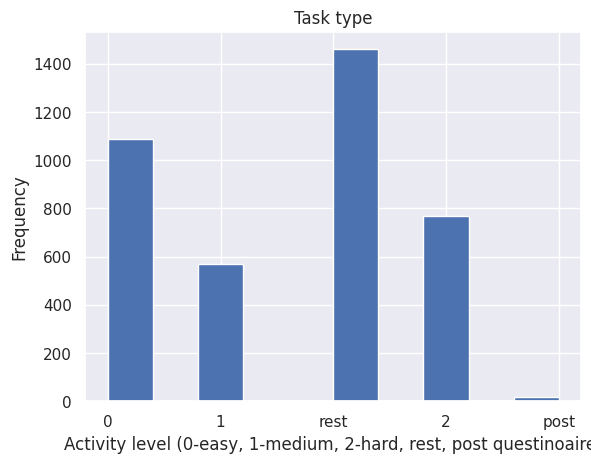

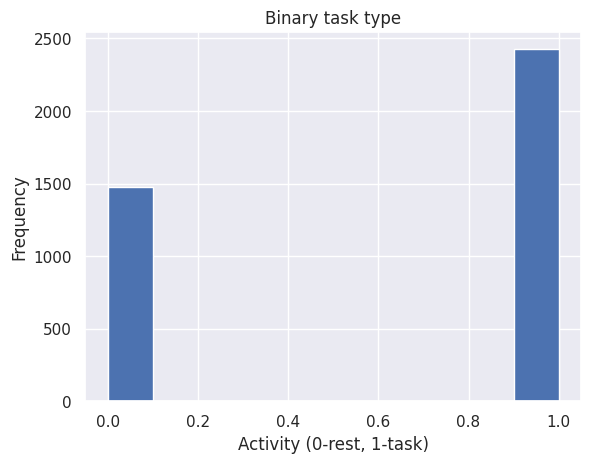

In [ ]:
#visualize the activities

df_sensor.level.hist()
plt.xlabel('Activity level (0-easy, 1-medium, 2-hard, rest, post questinoaire)')
plt.ylabel('Frequency')
plt.title("Task type")
plt.show()

print()
df_sensor.activity.hist()
plt.xlabel('Activity (0-rest, 1-task)')
plt.ylabel('Frequency')
plt.title('Binary task type')
plt.show()

**GSR**

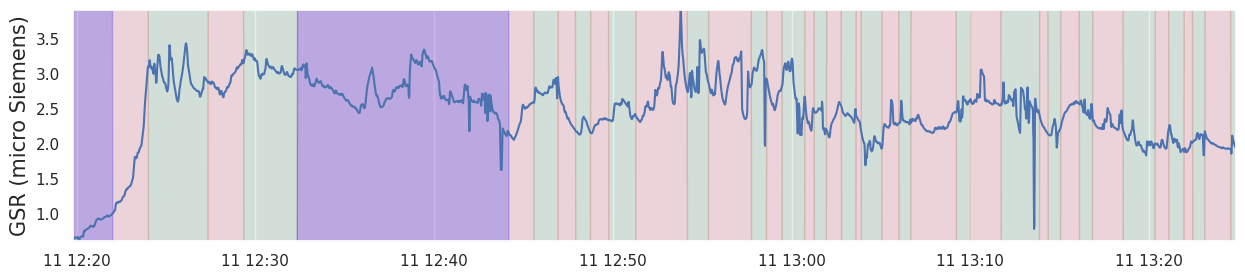

In [ ]:
plt.figure(figsize=(15,3))
#df_sensor.gsr.plot(fontsize=14)
ax = plt.axes()
ax.yaxis.grid()
scaler = df_sensor.gsr.max()
scaler_min = df_sensor.gsr.min()
#green represents rest periods + NASA TLX questionnaire
plt.fill_between(df_sensor.activity.index,df_sensor.activity*scaler,scaler, color='green',alpha=.1)
#red represents task periods
plt.fill_between(df_sensor.activity.index,df_sensor.activity*scaler,0, color='red',alpha=.1)
#purple represents personality and demographics questionnaire
plt.fill_between(df_sensor.activity.index,(df_sensor.task=='quest').astype(int)*scaler,0, color='blue',alpha=.2)

plt.ylim(scaler_min,scaler)
plt.ylabel('GSR (micro Siemens)',fontsize=15)
plt.xlim(df_sensor.index[0],df_sensor.index[-1])
plt.xlabel('')
plt.plot(df_sensor.gsr)

#plt.show()

**Heart Rate**

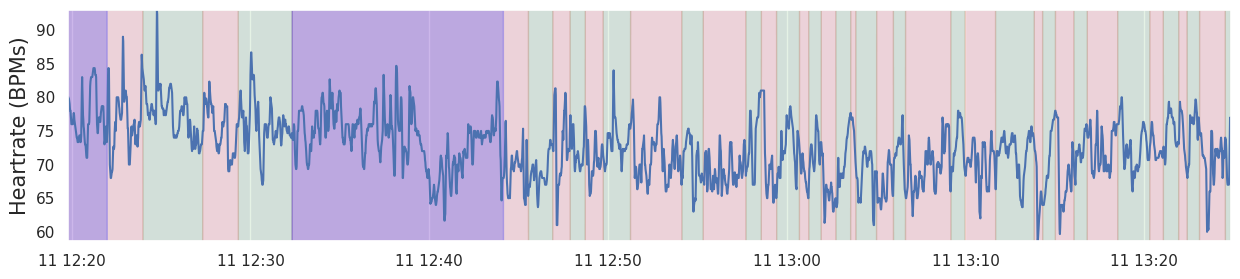

In [ ]:
plt.figure(figsize=(15,3))
#df_sensor.hr.plot(fontsize=14)
scaler = df_sensor.hr.max()
scaler_min = df_sensor.hr.min()
#green represents rest periods + NASA TLX questionnaire
plt.fill_between(df_sensor.activity.index,df_sensor.activity*scaler,scaler, color='green',alpha=.1)
#red represents task periods
plt.fill_between(df_sensor.activity.index,df_sensor.activity*scaler,0, color='red',alpha=.1)
#purple represents personality and demographics questionnaire
plt.fill_between(df_sensor.activity.index,(df_sensor.task=='quest').astype(int)*scaler,0, color='blue',alpha=.2)

ax = plt.gca()
ax.yaxis.grid()
plt.ylim(scaler_min,scaler)
plt.ylabel('Heartrate (BPMs)',fontsize=15)
plt.xlabel('')
plt.xlim(df_sensor.index[0],df_sensor.index[-1])
plt.plot(df_sensor.hr)
plt.show()


**RR intervals**

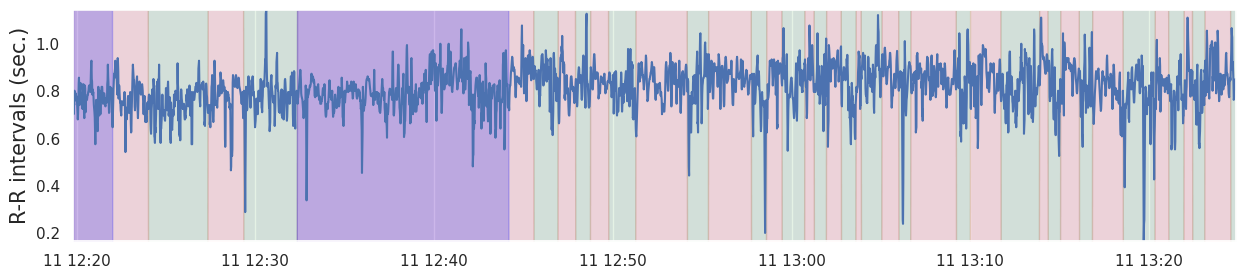

In [ ]:
plt.figure(figsize=(15,3))
#df_sensor.rr.plot(fontsize=14)
scaler = df_sensor.rr.max()
scaler_min = df_sensor.rr.min()
#green represents rest periods + NASA TLX questionnaire
plt.fill_between(df_sensor.activity.index,df_sensor.activity*scaler,scaler, color='green',alpha=.1)
#red represents task periods
plt.fill_between(df_sensor.activity.index,df_sensor.activity*scaler,0, color='red',alpha=.1)
#purple represents personality and demographics questionnaire
plt.fill_between(df_sensor.activity.index,(df_sensor.task=='quest').astype(int)*scaler,0, color='blue',alpha=.2)

ax = plt.gca()
ax.yaxis.grid()
plt.ylim(scaler_min,scaler)
plt.ylabel('R-R intervals (sec.)', fontsize=15)
plt.xlim(df_sensor.index[0],df_sensor.index[-1])
plt.plot(df_sensor.rr)
plt.xlabel('')
plt.show()


**Skin temperature**

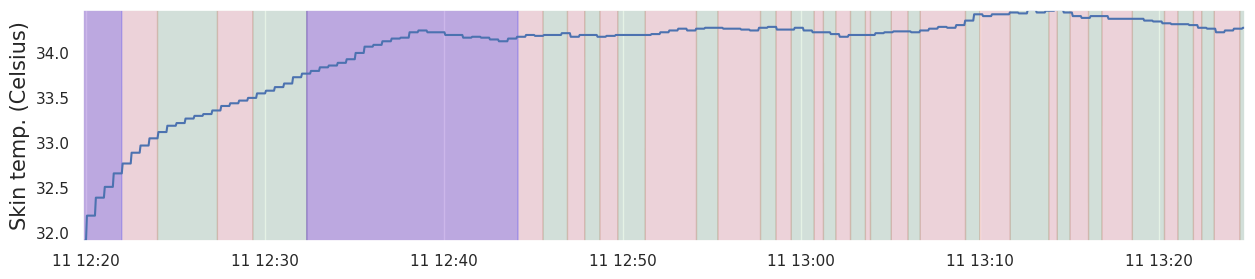

In [ ]:
plt.figure(figsize=(15,3))
#df_sensor.temperature.plot(fontsize=14)
scaler = df_sensor.temperature.max()
scaler_min = df_sensor.temperature.min()
#green represents rest periods + NASA TLX questionnaire
plt.fill_between(df_sensor.activity.index,df_sensor.activity*scaler,scaler, color='green',alpha=0.1)
#red represents task periods
plt.fill_between(df_sensor.activity.index,df_sensor.activity*scaler,0, color='red',alpha=0.1)
#purple represents personality and demographics questionnaire
plt.fill_between(df_sensor.activity.index,(df_sensor.task=='quest').astype(int)*scaler,0, color='blue',alpha=0.2)
plt.plot(df_sensor.temperature)

ax = plt.gca()
ax.yaxis.grid()
plt.ylim(scaler_min,scaler)
plt.ylabel('Skin temp. (Celsius)',fontsize=15)
plt.xlabel('')
plt.xlim(df_sensor.index[0],df_sensor.index[-1])
plt.show()


##Data segmentation

In [ ]:
data_folder_path = '/content/drive/MyDrive/CogLoad-1Hz/'

files = os.listdir(data_folder_path)

win_size = 30 #seconds

#lists to save 30second segments for each sensor
label_segments = []
temp_segments = []
hr_segments= []
gsr_segments= []
rr_segments= []
for file in files:
    if 'sensor' not in file:
      continue
    print()
    print('========')
    print('Reading data from:',file)
    df = pd.read_csv(data_folder_path+file)
    print(df.shape)
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    #print('Shape of data',df.shape)

    #for each task get segments task_end - 30 seconds (exclude'n2', 'n2_rest', 'n3', 'n3_rest')
    tasks = ['HP', 'HPrest', 'FA','FArest', 'GC', 'GCrest', 'NC', 'NCrest', 'SX', 'SXrest', 'PT','PTrest']

    for task in tasks:
        for level in df[df.task==task].level.unique():
            task_df = df[(df.task==task) & (df.level==level)]
            print('Segments for task',task,level,task_df.task.unique())
            if len(task_df)>0:
                if 'rest' in task and 'n2' not in task and 'n3' not in task:
                    if 'e4gay' in task_df.user_id.values and 'HPrest' in task_df.task.values:
                      #print(task_df.timestamp)
                      df_e4gayTask=task_df

                    timestamp_end_arr = []

                    task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
                    # Filter rows where the time difference to the next timestamp is greater than 5 seconds
                    selected_df = task_df[task_df['time_diff'] > 5000]
                    timestamp_end_arr.extend(selected_df.timestamp.values)

                    # Drop the time_diff column if no longer needed
                    task_df = task_df.drop(columns='time_diff')

                    #timestamp_end_arr.extend(task_df[task_df.timestamp.diff()>10000].timestamp.values)
                    timestamp_end_arr.append(task_df.timestamp.iloc[-1])
                    print(task,timestamp_end_arr)
                    for segment_end in timestamp_end_arr:

                        segment_sensor_data = task_df[task_df.timestamp<segment_end]
                        segment_sensor_data = segment_sensor_data.iloc[-win_size:]

                        print('REST',segment_sensor_data.shape,segment_end)
                        if segment_sensor_data.shape[0]==win_size:
                            label_segments.append(segment_sensor_data.iloc[-1].values)
                            temp_segments.append(segment_sensor_data.temperature.values[:win_size])
                            hr_segments.append(segment_sensor_data.hr.values[:win_size])
                            gsr_segments.append(segment_sensor_data.gsr.values[:win_size])
                            rr_segments.append(segment_sensor_data.rr.values[:win_size])
                else:
                    segment_end = task_df.timestamp.iloc[-1]
                    segment_start= segment_end - win_size*1000
                    segment_sensor_data =task_df[(task_df.timestamp<=segment_end) & (task_df.timestamp>=segment_start)]
                    if segment_sensor_data.shape[0]>25 and segment_sensor_data.shape[0]<win_size:
                        print('segment_sensor_data',segment_sensor_data.shape,'added 5 seconds')
                        segment_sensor_data =df[(df.timestamp<=segment_end) & (df.timestamp>=segment_start)]
                    if len(segment_sensor_data)>=win_size:
                        label_segments.append(segment_sensor_data.iloc[-1].values)
                        temp_segments.append(segment_sensor_data.temperature.values[:win_size])
                        hr_segments.append(segment_sensor_data.hr.values[:win_size])
                        gsr_segments.append(segment_sensor_data.gsr.values[:win_size])
                        rr_segments.append(segment_sensor_data.rr.values[:win_size])

label_segments = np.stack(label_segments)
temp_segments = np.stack(temp_segments)
hr_segments = np.stack(hr_segments)
gsr_segments = np.stack(gsr_segments)
rr_segments = np.stack(rr_segments)


Reading data from: yljm5_sensors.csv
(4176, 21)
Segments for task HP 2 ['HP']
Segments for task HP 0 ['HP']
Segments for task HP 1 ['HP']
Segments for task HPrest rest ['HPrest']
HPrest [1508491107498, 1508491231492, 1508491374494]
REST (30, 21) 1508491107498
REST (30, 21) 1508491231492
REST (30, 21) 1508491374494
Segments for task FA 2 ['FA']
Segments for task FA 1 ['FA']
Segments for task FA 0 ['FA']
Segments for task FArest rest ['FArest']
FArest [1508491511492, 1508491753504, 1508491945503]
REST (30, 21) 1508491511492
REST (30, 21) 1508491753504
REST (30, 21) 1508491945503
Segments for task GC 1 ['GC']
Segments for task GC 2 ['GC']
Segments for task GC 0 ['GC']
segment_sensor_data (26, 21) added 5 seconds
Segments for task GCrest rest ['GCrest']
GCrest [1508492040508, 1508492138508, 1508492254503]
REST (30, 21) 1508492040508
REST (30, 21) 1508492138508
REST (30, 21) 1508492254503
Segments for task NC 0 ['NC']
Segments for task NC 2 ['NC']
Segments for task NC 1 ['NC']
Segments for

<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

(4056, 21)
Segments for task HP 2 ['HP']
Segments for task HP 0 ['HP']
Segments for task HP 1 ['HP']
Segments for task HPrest rest ['HPrest']
HPrest [1503932573506, 1503932684510, 1503932840503]
REST (30, 21) 1503932573506
REST (30, 21) 1503932684510
REST (30, 21) 1503932840503
Segments for task FA 2 ['FA']
Segments for task FA 1 ['FA']
Segments for task FA 0 ['FA']
Segments for task FArest rest ['FArest']
FArest [1503932980505, 1503933111500, 1503933250513]
REST (30, 21) 1503932980505
REST (30, 21) 1503933111500
REST (30, 21) 1503933250513
Segments for task GC 1 ['GC']
Segments for task GC 2 ['GC']
Segments for task GC 0 ['GC']
Segments for task GCrest rest ['GCrest']
GCrest [1503933365497, 1503933518499, 1503933635505]
REST (30, 21) 1503933365497
REST (30, 21) 1503933518499
REST (30, 21) 1503933635505
Segments for task NC 0 ['NC']
Segments for task NC 2 ['NC']
Segments for task NC 1 ['NC']
Segments for task NCrest rest ['NCrest']
NCrest [1503933736496, 1503933913495, 1503934088494]
R

<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

(5600, 21)
Segments for task HP 2 ['HP']
Segments for task HP 0 ['HP']
Segments for task HP 1 ['HP']
Segments for task HPrest rest ['HPrest']
HPrest [1508423645495, 1508423741496, 1508423941499]
REST (30, 21) 1508423645495
REST (30, 21) 1508423741496
REST (30, 21) 1508423941499
Segments for task FA 2 ['FA']
Segments for task FA 1 ['FA']
Segments for task FA 0 ['FA']
Segments for task FArest rest ['FArest']
FArest [1508424187504, 1508424337492, 1508424506511]
REST (30, 21) 1508424187504
REST (30, 21) 1508424337492
REST (30, 21) 1508424506511
Segments for task GC 1 ['GC']
Segments for task GC 2 ['GC']
Segments for task GC 0 ['GC']
Segments for task GCrest rest ['GCrest']
GCrest [1508424635514, 1508424777503, 1508424884498]
REST (30, 21) 1508424635514
REST (30, 21) 1508424777503
REST (30, 21) 1508424884498
Segments for task NC 0 ['NC']
Segments for task NC 2 ['NC']
Segments for task NC 1 ['NC']
Segments for task NCrest rest ['NCrest']
NCrest [1508425039495, 1508425270498, 1508425483500]
R

...

<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

(3339, 21)
Segments for task HP 2 ['HP']
Segments for task HP 0 ['HP']
Segments for task HP 1 ['HP']
Segments for task HPrest rest ['HPrest']
HPrest [1504879589488, 1504879706487, 1504879844503]
REST (30, 21) 1504879589488
REST (30, 21) 1504879706487
REST (30, 21) 1504879844503
Segments for task FA 2 ['FA']
Segments for task FA 1 ['FA']
Segments for task FA 0 ['FA']
Segments for task FArest rest ['FArest']
FArest [1504879981505, 1504880035484, 1504880071511, 1504880179483]
REST (30, 21) 1504879981505
REST (30, 21) 1504880035484
REST (30, 21) 1504880071511
REST (30, 21) 1504880179483
Segments for task GC 1 ['GC']
Segments for task GC 2 ['GC']
Segments for task GC 0 ['GC']
Segments for task GCrest rest ['GCrest']
GCrest [1504880333484, 1504880475503, 1504880596500]
REST (30, 21) 1504880333484
REST (30, 21) 1504880475503
REST (30, 21) 1504880596500
Segments for task NC 0 ['NC']
Segments for task NC 2 ['NC']
Segments for task NC 1 ['NC']
Segments for task NCrest rest ['NCrest']
NCrest [150

<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

(4237, 21)
Segments for task HP 2 ['HP']
Segments for task HP 0 ['HP']
Segments for task HP 1 ['HP']
Segments for task HPrest rest ['HPrest']
HPrest [1508337733497, 1508337845501, 1508338018496]
REST (30, 21) 1508337733497
REST (30, 21) 1508337845501
REST (30, 21) 1508338018496
Segments for task FA 2 ['FA']
Segments for task FA 1 ['FA']
Segments for task FA 0 ['FA']
Segments for task FArest rest ['FArest']
FArest [1508338219494, 1508338451496, 1508338713510]
REST (30, 21) 1508338219494
REST (30, 21) 1508338451496
REST (30, 21) 1508338713510
Segments for task GC 1 ['GC']
Segments for task GC 2 ['GC']
Segments for task GC 0 ['GC']
Segments for task GCrest rest ['GCrest']
GCrest [1508338837500, 1508338937504, 1508339033499]
REST (30, 21) 1508338837500
REST (30, 21) 1508338937504
REST (30, 21) 1508339033499
Segments for task NC 0 ['NC']
Segments for task NC 2 ['NC']
Segments for task NC 1 ['NC']
Segments for task NCrest rest ['NCrest']
NCrest [1508339164506, 1508339391495, 1508339563492]
R

<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['time_diff'] = task_df['timestamp'].diff(periods=-1).abs()
<ipython-input-13-2183ec0422ae>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

In [ ]:
#check the 30-second segments
print("Number of segments for each type of sensor data")
print('Labels',label_segments.shape)
print('Temperature',temp_segments.shape)
print('Heartrate',hr_segments.shape)
print('GSR',gsr_segments.shape)
print('RR',rr_segments.shape)


Number of segments for each type of sensor data
Labels (749, 21)
Temperature (749, 30)
Heartrate (749, 30)
GSR (749, 30)
RR (749, 30)


In [ ]:
#convers the lists to dataframes for easier manipulation
column_names = segment_sensor_data.columns.values
label_df = pd.DataFrame(label_segments,columns = column_names)
label_df.head()

,datetime,timestamp,user_id,level,task,hr,gsr,rr,temperature,TLX_mean,...,TLX_physical_demand,TLX_temporal_demand,TLX_performance,TLX_effort,TLX_frustration,band_ax,band_ay,band_az,opacity_median,opacity_std
0,2017-10-20 09:17:07,1508491026511,yljm5,2,HP,95.333333,0.75624,0.602843,32.330002,9,...,1,1,2,3,1,0.203003,0.376587,0.896769,0.101961,0.022926
1,2017-10-20 09:19:33,1508491172492,yljm5,0,HP,105.0,0.722979,0.536475,32.360001,7,...,1,2,1,1,1,0.22465,0.337524,0.906494,0.094118,0.031185
2,2017-10-20 09:21:25,1508491284492,yljm5,1,HP,95.333333,0.68244,0.569659,32.389999,7,...,1,1,1,2,1,0.215942,0.239014,0.939209,0.094118,0.007711
3,2017-10-20 09:18:27,1508491106498,yljm5,rest,HPrest,92.333333,0.704401,0.680272,32.349998,-1,...,-1,-1,-1,-1,-1,-0.646728,0.074585,0.675578,-1.0,-1.0
4,2017-10-20 09:20:31,1508491230492,yljm5,rest,HPrest,77.666667,0.705385,0.680272,32.369999,-1,...,-1,-1,-1,-1,-1,0.218425,0.236165,0.939575,-1.0,-1.0


In [ ]:
#converst the lists to dataframes for easier manipulation
temp_df= pd.DataFrame(temp_segments)
hr_df= pd.DataFrame(hr_segments)
gsr_df= pd.DataFrame(gsr_segments)
rr_df= pd.DataFrame(rr_segments)
print(temp_df.shape,hr_df.shape,gsr_df.shape,rr_df.shape)

(749, 30) (749, 30) (749, 30) (749, 30)


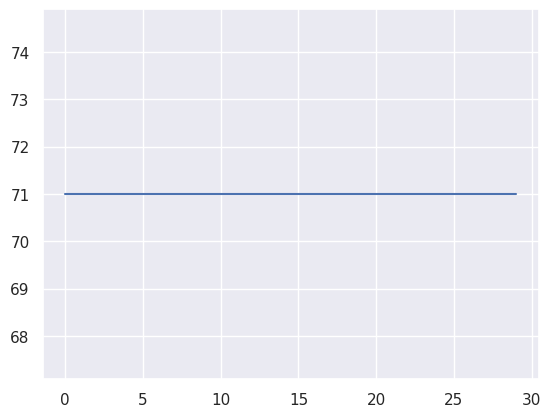

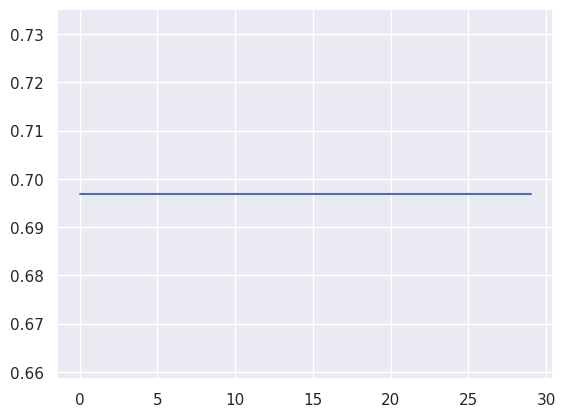

,99
datetime,2017-10-19 15:13:46
timestamp,1508426025502
user_id,b7mrd
level,1
task,PT
hr,71.0
gsr,1.041667
rr,0.696864
temperature,33.57
TLX_mean,13


In [ ]:
hr_df.iloc[99,:].plot()
plt.show()

rr_df.iloc[99,:].plot()
plt.show()

label_df.iloc[99,:]

## Exploratory data analysis over raw data
Group sensor data by level of congitve load and plot it using violinplots

In [ ]:
#create a dataframe for easier data manipulation
stat_df = []
for user in label_df.user_id.unique(): #iterate the data for each user
  print()
  print('=====',user)
  user_labels = label_df[label_df.user_id==user] #select only user data
  user_tmp  = temp_df[label_df.user_id==user]
  user_hr = hr_df[label_df.user_id==user]
  user_gsr= gsr_df[label_df.user_id==user]
  user_rr = rr_df[label_df.user_id==user]

  #for each user and each level there are several 30-second segments
  #calculate mean values and standard deviation over those segments
  for level in user_labels.level.unique():
    print(level)
    temp = user_tmp[user_labels.level==level].mean().mean()
    hr = user_hr[user_labels.level==level].mean().mean()
    gsr = user_gsr[user_labels.level==level].mean().mean()
    rr = user_rr[user_labels.level==level].mean().mean()

    s_temp = user_tmp[user_labels.level==level].std().mean()
    s_hr = user_hr[user_labels.level==level].std().mean()
    s_gsr = user_gsr[user_labels.level==level].std().mean()
    s_rr = user_rr[user_labels.level==level].std().mean()

    row = [user,level,temp,hr,gsr,rr,s_temp,s_hr,s_gsr,s_rr]
    stat_df.append(row)

columns = ['user','level','mean_T','mean_HR','mean_GSR','mean_RR',
           'std_T','std_HR','std_GSR','std_RR']
stat_df = pd.DataFrame(stat_df,columns = columns)


===== yljm5
2
0
1
rest

===== f1gjp
2
0
1
rest

===== b7mrd
2
0
1
rest

===== 6frz4
2
0
1
rest

===== f3j25
2
0
1
rest

===== 8a1ep
2
0
1
rest

===== e4gay
2
0
1
rest

===== 3caqi
2
0
1
rest

===== tn4vl
2
0
1
rest

===== wjxci
2
0
1
rest

===== ef5rq
2
0
1
rest

===== c24ur
2
0
1
rest

===== iz2ps
2
0
1
rest

===== 7swyk
2
0
1
rest

===== ibvx8
2
0
1
rest

===== 5gpsc
2
0
1
rest

===== dkhty
2
0
1
rest

===== hpbxa
2
0
1
rest

===== 1mpau
2
0
1
rest

===== rc1in
2
0
1
rest

===== iz3x1
2
0
1
rest

===== bd47a
2
0
1
rest

===== 2nxs5
2
0
1
rest


In [ ]:
stat_df

,user,level,mean_T,mean_HR,mean_GSR,mean_RR,std_T,std_HR,std_GSR,std_RR
0,yljm5,2,32.493889,94.007407,0.721892,0.645936,0.104233,8.932622,0.102241,0.090647
1,yljm5,0,32.497834,96.098148,0.776463,0.621509,0.080394,8.271458,0.122819,0.065672
2,yljm5,1,32.515723,96.827778,0.722215,0.619926,0.078624,7.876343,0.101189,0.065645
3,yljm5,rest,32.502177,91.844118,0.750747,0.657450,0.075501,11.288394,0.124785,0.124096
4,f1gjp,2,32.404963,81.600000,7.020287,0.724118,0.629168,3.045201,0.606285,0.040903
...,...,...,...,...,...,...,...,...,...,...
87,bd47a,rest,32.836173,62.115432,6.725321,0.989544,0.235093,4.214901,1.071407,0.107705
88,2nxs5,2,32.888389,79.095370,1.550519,0.731723,0.178863,6.003633,0.855683,0.080246
89,2nxs5,0,32.938777,80.011111,1.809593,0.749528,0.165409,7.173137,0.651444,0.067876
90,2nxs5,1,32.975640,81.340741,1.728502,0.734073,0.203714,4.676797,0.694610,0.082329


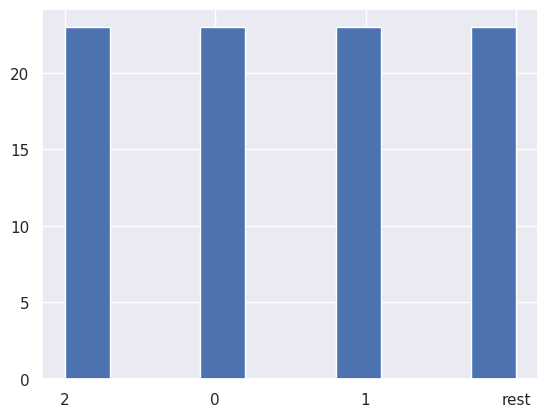

In [ ]:
stat_df.level.hist()
plt.show()

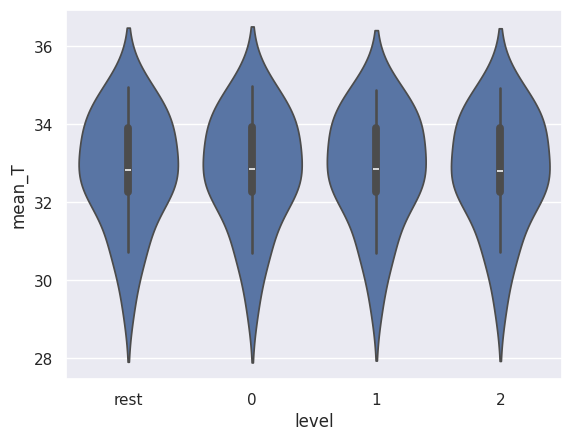

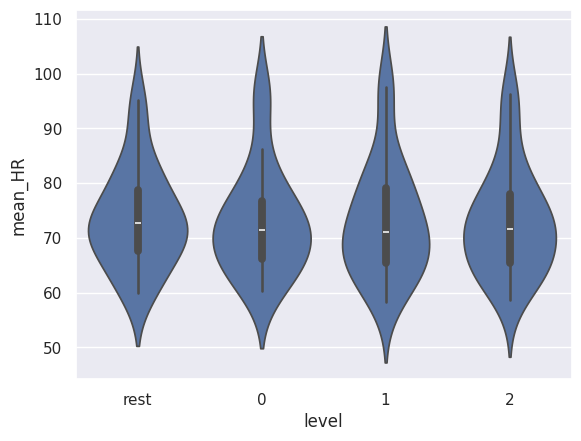

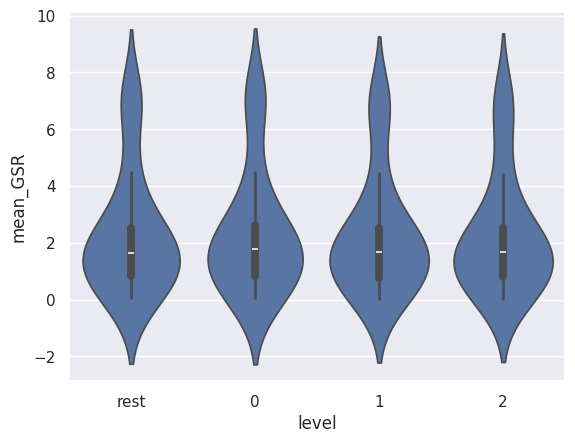

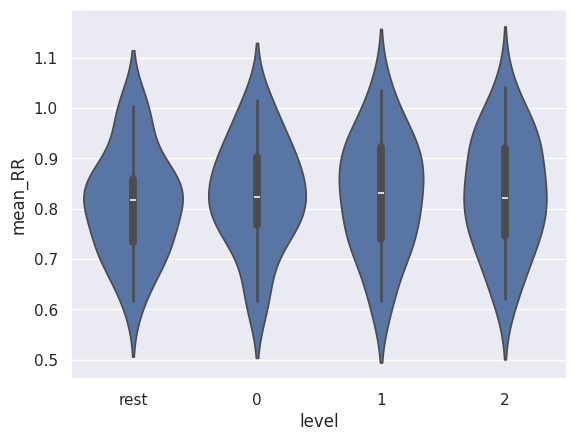

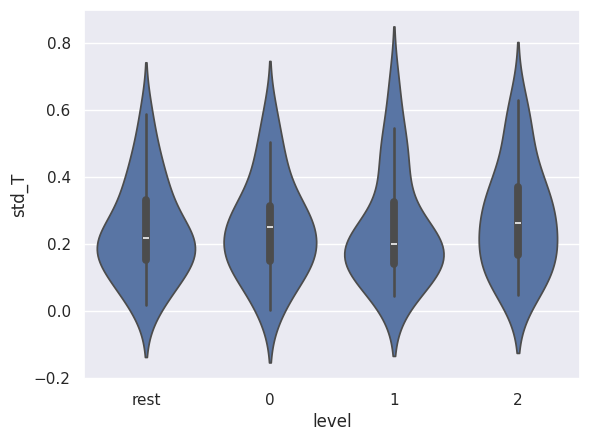

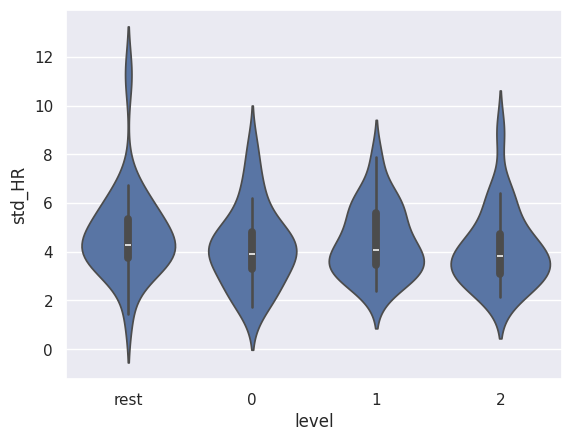

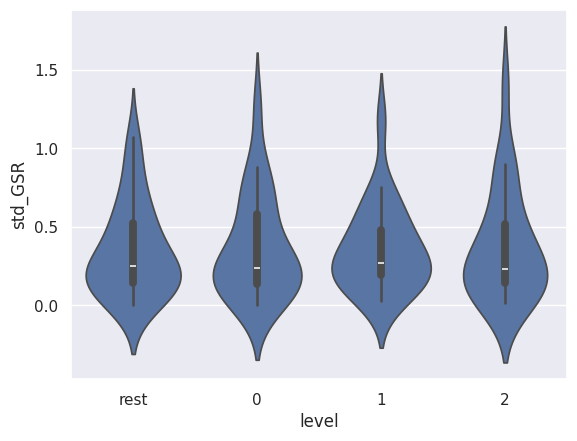

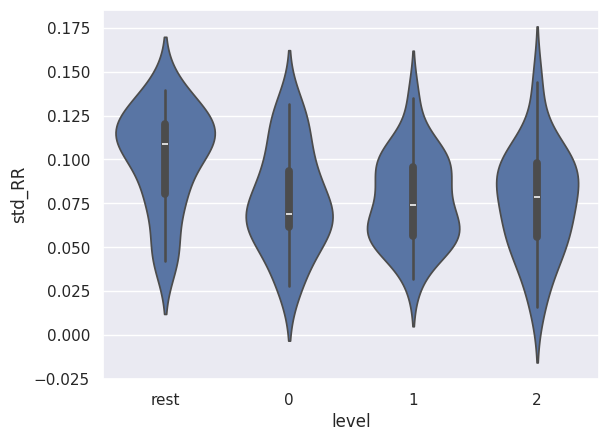

In [ ]:
sns.set()
for col_name in ['mean_T','mean_HR','mean_GSR','mean_RR',
                 'std_T','std_HR','std_GSR','std_RR']:
  sns.violinplot(x="level", y=col_name,
              data=stat_df,
              order=['rest','0','1','2'])
  print()
  plt.show()

## Save data to file

Save segmented data to files (on Google Drive) for further processing. Each data type will be saved in a separate file.

In [ ]:
data_folder_path = '/content/drive/MyDrive/CogLoad-1Hz/'

print('Saving data to folder', data_folder_path)
label_df.to_csv(data_folder_path+'segments_labels.csv')
temp_df.to_csv(data_folder_path+'segments_temperature.csv')
hr_df.to_csv(data_folder_path+'segments_heartrate.csv')
gsr_df.to_csv(data_folder_path+'segments_gsr.csv')
rr_df.to_csv(data_folder_path+'segments_rr.csv')
print('Done')

Saving data to folder /content/drive/MyDrive/CogLoad-1Hz/
Done


##Part 2.2: Machine Learning

Reference Code: https://colab.research.google.com/drive/1adYKWqgSsky0z5LITB9QjsFTmL7g90gH?usp=sharing#scrollTo=6l2qva9X-mW2

<img src=https://www.mdpi.com/sensors/sensors-20-06535/article_deploy/html/images/sensors-20-06535-g001.png width = 1204 >
Image from: Dzieżyc, M., Gjoreski, M., Kazienko, P., Saganowski, S., & Gams, M. (2020). Can we ditch feature engineering? end-to-end deep learning for affect recognition from physiological sensor data. Sensors, 20(22), 6535.

## Import python libraries

In [ ]:
#to access files and folders
import os
#data analysis and manipulation library
import pandas as pd
#math operations for multi-dimensional arrays and matrices
import numpy as np
#visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set() #use a specific color theme

import warnings
warnings.simplefilter("ignore")#ignore warnings during execution

#ML libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

from sklearn.model_selection import GroupKFold
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV

## Data reading
We segmented the data into 30-second windows in Part 1 of this tutorial. Now, we will read the segmented data

In [ ]:
#Connect this Google Colab to your peronal Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#read the data
data_folder_path = '/content/drive/MyDrive/CogLoad-1Hz/'
print('Reading data')
label_df = pd.read_csv(data_folder_path+'segments_labels.csv',index_col=0)
temp_df= pd.read_csv(data_folder_path+'segments_temperature.csv',index_col=0)
hr_df= pd.read_csv(data_folder_path+'segments_heartrate.csv',index_col=0)
gsr_df = pd.read_csv(data_folder_path+'segments_gsr.csv',index_col=0)
rr_df= pd.read_csv(data_folder_path+'segments_rr.csv',index_col=0)
print('Done')

#check 30-second segments
print("Data shapes:")
print('Labels',label_df.shape)
print('Temperature',temp_df.shape)
print('Heartrate',hr_df.shape)
print('GSR',gsr_df.shape)
print('RR',rr_df.shape)

Reading data
Done
Data shapes:
Labels (749, 21)
Temperature (749, 30)
Heartrate (749, 30)
GSR (749, 30)
RR (749, 30)


## Data check

In [ ]:
label_df.head()

,datetime,timestamp,user_id,level,task,hr,gsr,rr,temperature,TLX_mean,...,TLX_physical_demand,TLX_temporal_demand,TLX_performance,TLX_effort,TLX_frustration,band_ax,band_ay,band_az,opacity_median,opacity_std
0,2017-10-20 09:17:07,1508491026511,yljm5,2,HP,95.333333,0.756240,0.602843,32.330002,9,...,1,1,2,3,1,0.203003,0.376587,0.896769,0.101961,0.022926
1,2017-10-20 09:19:33,1508491172492,yljm5,0,HP,105.000000,0.722979,0.536475,32.360001,7,...,1,2,1,1,1,0.224650,0.337524,0.906494,0.094118,0.031185
2,2017-10-20 09:21:25,1508491284492,yljm5,1,HP,95.333333,0.682440,0.569659,32.389999,7,...,1,1,1,2,1,0.215942,0.239014,0.939209,0.094118,0.007711
3,2017-10-20 09:18:27,1508491106498,yljm5,rest,HPrest,92.333333,0.704401,0.680272,32.349998,-1,...,-1,-1,-1,-1,-1,-0.646728,0.074585,0.675578,-1.000000,-1.000000
4,2017-10-20 09:20:31,1508491230492,yljm5,rest,HPrest,77.666667,0.705385,0.680272,32.369999,-1,...,-1,-1,-1,-1,-1,0.218425,0.236165,0.939575,-1.000000,-1.000000


In [ ]:
hr_df.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,96.333333,97.666667,98.333333,98.666667,97.333333,96.000000,95.000000,95.000000,95.0,95.000000,...,99.000000,99.333333,99.333333,100.333333,99.666667,98.333333,95.666667,94.666667,94.333333,95.333333
1,100.333333,101.000000,101.666667,102.000000,102.333333,103.000000,104.000000,105.333333,106.0,106.000000,...,105.333333,106.000000,107.000000,108.000000,108.666667,108.666667,106.333333,104.000000,102.000000,103.000000
2,100.666667,102.333333,103.333333,104.000000,107.000000,108.333333,109.000000,108.000000,107.0,106.666667,...,111.666667,111.000000,110.000000,101.333333,92.666667,84.666667,85.333333,86.333333,89.666667,92.333333
3,89.666667,94.333333,98.000000,100.666667,99.666667,98.666667,98.000000,97.333333,97.0,100.333333,...,100.333333,99.333333,98.000000,97.666667,97.333333,97.000000,95.666667,94.333333,93.333333,92.333333
4,102.000000,101.000000,100.666667,100.000000,98.333333,96.666667,95.666667,95.666667,103.0,109.666667,...,70.333333,71.333333,72.333333,72.000000,73.333333,75.000000,77.333333,77.666667,77.666667,77.666667


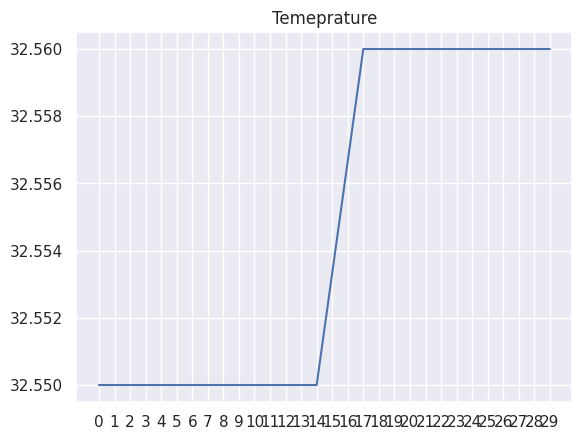

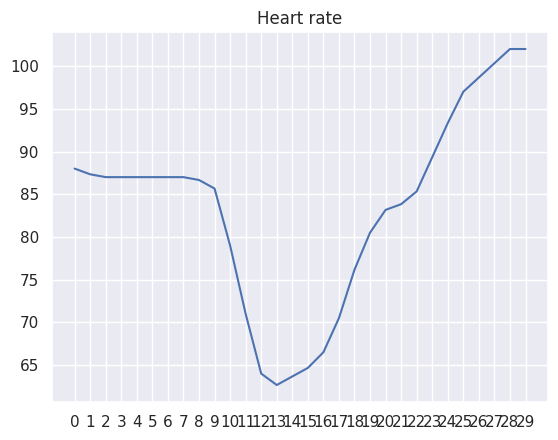

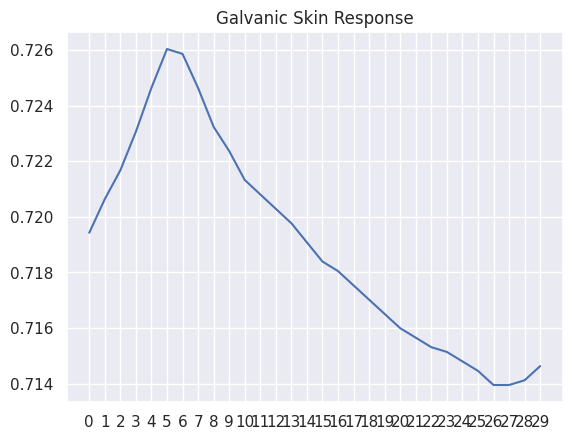

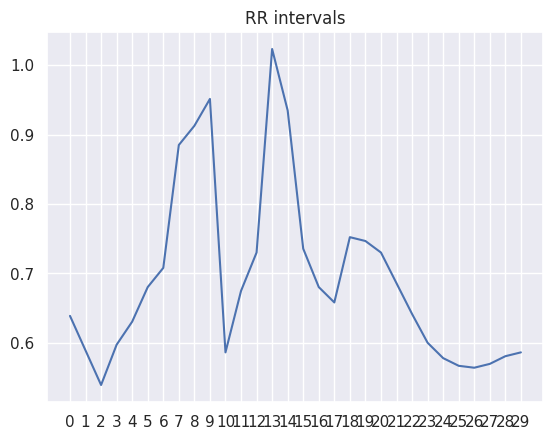

In [ ]:
#plot first segmend from each data type
segment_index = 22


plt.plot(temp_df.iloc[segment_index])
plt.title('Temeprature')
plt.show()
print()

plt.plot(hr_df.iloc[segment_index])
plt.title('Heart rate')
plt.show()
print()

plt.plot(gsr_df.iloc[segment_index])
plt.title('Galvanic Skin Response')
plt.show()
print()

plt.plot(rr_df.iloc[segment_index])
plt.title('RR intervals')
plt.show()
print()

In [ ]:
user_id = 'iz3x1' #change this to access other users' data. For example [3caqi,iz3x1,... dkhty]
example_data_path = data_folder_path+user_id+'_sensors.csv'
df_sensor = pd.read_csv(example_data_path)
df_sensor.head()

,datetime,timestamp,user_id,level,task,hr,gsr,rr,temperature,TLX_mean,...,TLX_physical_demand,TLX_temporal_demand,TLX_performance,TLX_effort,TLX_frustration,band_ax,band_ay,band_az,opacity_median,opacity_std
0,2017-10-11 12:19:18,1507724357634,iz3x1,0,quest,40.666667,NaN,0.000000,21.166667,-1,...,-1,-1,-1,-1,-1,0.074789,0.286621,0.591797,-1.0,-1.0
1,2017-10-11 12:19:19,1507724358502,iz3x1,0,quest,61.000000,NaN,0.182512,31.750000,-1,...,-1,-1,-1,-1,-1,0.111573,0.430338,0.887858,-1.0,-1.0
2,2017-10-11 12:19:20,1507724359493,iz3x1,0,quest,61.000000,0.683460,0.464576,31.750000,-1,...,-1,-1,-1,-1,-1,0.110311,0.430460,0.888753,-1.0,-1.0
3,2017-10-11 12:19:21,1507724360491,iz3x1,0,quest,61.000000,0.671190,0.746640,31.750000,-1,...,-1,-1,-1,-1,-1,0.105184,0.442749,0.882731,-1.0,-1.0
4,2017-10-11 12:19:22,1507724361491,iz3x1,0,quest,61.000000,0.662344,0.696864,31.750000,-1,...,-1,-1,-1,-1,-1,0.100301,0.454305,0.877441,-1.0,-1.0


## Data filtering

Data from wearable sensors is usually noisy. To minimise the influence of the noise on the analysis, a variety of filtering techniques can be used. One simple technique that we will try in here is moving average.

### Moving average

In [ ]:
#apply moving average to each 30-second segment separately
temp_df_ma = temp_df.rolling(3,axis=1).mean()

hr_df_ma = hr_df.rolling(3,axis=1).mean()
gsr_df_ma = gsr_df.rolling(3,axis=1).mean()
rr_df_ma = rr_df.rolling(3,axis=1).mean()

### Vizualize difference

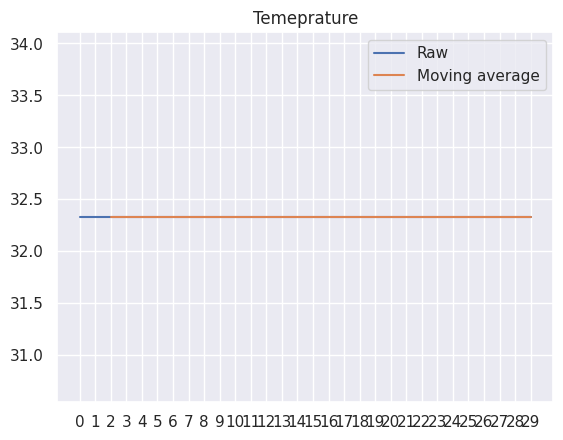

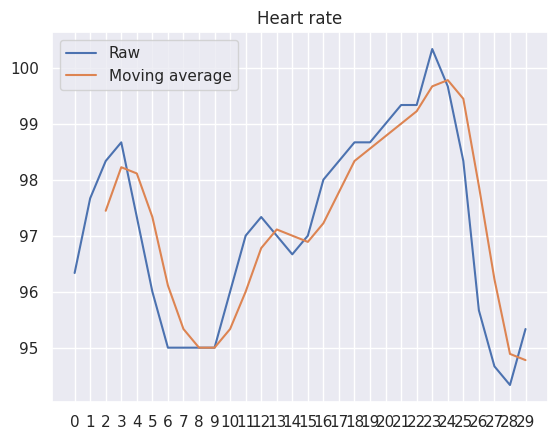

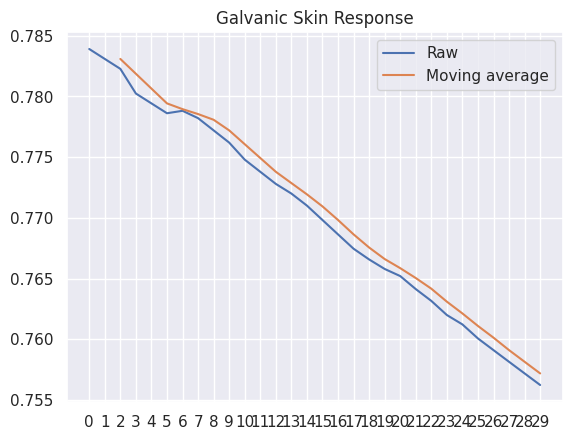

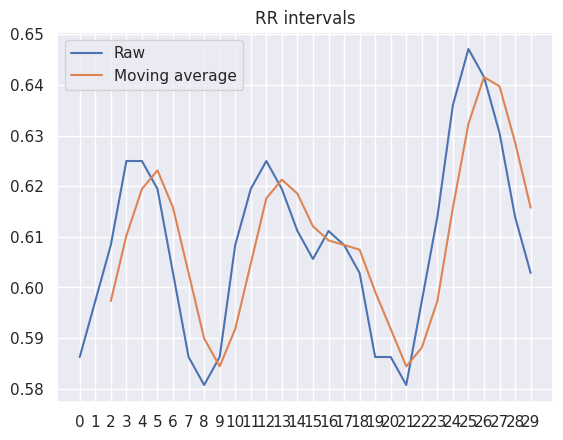

In [ ]:
#plot first segmend from each data type (raw and fitlered values)
plt.plot(temp_df.iloc[0],label='Raw')
plt.plot(temp_df_ma.iloc[0],label='Moving average')
plt.title('Temeprature')
plt.legend()
plt.show()
print()

plt.plot(hr_df.iloc[0],label='Raw')
plt.plot(hr_df_ma.iloc[0],label='Moving average')
plt.title('Heart rate')
plt.legend()
plt.show()
print()


plt.plot(gsr_df.iloc[0],label='Raw')
plt.plot(gsr_df_ma.iloc[0],label='Moving average')
plt.title('Galvanic Skin Response')
plt.legend()
plt.show()
print()


plt.plot(rr_df.iloc[0],label='Raw')
plt.plot(rr_df_ma.iloc[0],label='Moving average')
plt.title('RR intervals')
plt.legend()
plt.show()
print()

## Feature extraction

### Statistical features

In [ ]:
def extract_stat_features(df,data_type=''):
  stat_features_names= ['mean','std','skew','kurtosis','diff','diff2','q25','q75','qdev','max-min']
  final_names =  [data_type + '_'+x for x in stat_features_names]
  features = pd.DataFrame(columns = stat_features_names) #create empty dataframe
  values = [df.mean(axis=1).values, #mean
            df.std(axis=1).values,  #standard deviation
            df.skew(axis=1).values, #skewness
            df.kurtosis(axis=1).values, #kurtosis
            df.diff(axis=1).mean(axis=1).values, #mean value of first derivative
            df.diff(axis=1).diff(axis=1).mean(axis=1).values, #mean value of second derivative
            df.quantile(0.25,axis=1).values, #25th quantile
            df.quantile(0.75,axis=1).values,#75th quantile
            df.quantile(0.75,axis=1).values-df.quantile(0.25,axis=1).values, #quartile deviation
            df.max(axis=1).values-df.min(axis=1).values] #range
  values  = np.column_stack(values)
  return pd.DataFrame(values,columns = final_names)

#extract features from temeprature data
temp_stat_features = extract_stat_features(temp_df_ma,'temp')
temp_stat_features.shape, temp_df_ma.shape

((749, 10), (749, 30))

In [ ]:
temp_stat_features

,temp_mean,temp_std,temp_skew,temp_kurtosis,temp_diff,temp_diff2,temp_q25,temp_q75,temp_qdev,temp_max-min
0,32.330002,1.447163e-14,0.000000,0.000000,0.000000,0.0,32.330002,32.330002,0.000000,0.000000
1,32.356428,4.630442e-03,-0.627772,-1.632652,0.000370,0.0,32.349998,32.360001,0.010002,0.010002
2,32.383572,4.628676e-03,0.627772,-1.632652,0.000370,0.0,32.380001,32.389999,0.009998,0.009998
3,32.349998,1.447163e-14,0.000000,0.000000,0.000000,0.0,32.349998,32.349998,0.000000,0.000000
4,32.369999,0.000000e+00,0.000000,0.000000,0.000000,0.0,32.369999,32.369999,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
744,32.957501,2.507705e-02,-1.753485,1.408276,0.002593,0.0,32.968057,32.970001,0.001944,0.070000
745,32.981786,3.583216e-03,1.753485,1.408276,-0.000370,0.0,32.980000,32.980277,0.000278,0.010002
746,32.870001,9.705528e-03,0.000000,-2.073596,-0.000741,0.0,32.860001,32.880001,0.020000,0.020000
747,32.990002,0.000000e+00,0.000000,0.000000,0.000000,0.0,32.990002,32.990002,0.000000,0.000000


In [ ]:
#extract features from heart-rate data
hr_stat_features = extract_stat_features(hr_df_ma,'hr')
#extract features from GSR data
gsr_stat_features = extract_stat_features(gsr_df_ma,'gsr')
#extract features from RR data
rr_stat_features = extract_stat_features(rr_df_ma,'rr')
print(temp_stat_features.shape,hr_stat_features.shape,gsr_stat_features.shape,rr_stat_features.shape)

(749, 10) (749, 10) (749, 10) (749, 10)


In [ ]:
hr_stat_features

,hr_mean,hr_std,hr_skew,hr_kurtosis,hr_diff,hr_diff2,hr_q25,hr_q75,hr_qdev,hr_max-min
0,97.257937,1.553218,-0.090202,-1.088687,-0.098765,-0.034188,96.083333,98.388889,2.305556,5.000000
1,104.658730,1.856520,0.166114,-0.130298,0.074074,-0.064103,103.777778,105.777778,2.000000,7.444444
2,104.583333,8.355588,-1.261196,0.570085,-0.469136,0.047009,102.944444,109.166667,6.222222,28.555556
3,99.670635,3.456898,0.128239,-0.671011,-0.024691,-0.183761,97.611111,101.916667,4.305556,12.444444
4,89.809524,16.422738,0.063894,-1.613681,-0.872428,0.029915,73.222222,101.611111,28.388889,47.222222
...,...,...,...,...,...,...,...,...,...,...
744,75.210317,1.555949,-0.513726,-1.217971,-0.144033,-0.021368,73.861111,76.416667,2.555556,4.555556
745,71.289683,1.237406,-0.526856,-1.255443,0.012346,0.051282,70.000000,72.444444,2.444444,3.444444
746,71.367063,4.404095,1.264280,0.905283,0.481481,0.053419,67.847222,72.611111,4.763889,15.111111
747,75.801587,1.065464,0.247513,0.103428,0.156379,0.017094,75.277778,76.166667,0.888889,4.222222


In [ ]:
#merge all statistical features into one table
stat_feat_all = pd.concat([temp_stat_features,hr_stat_features,gsr_stat_features,rr_stat_features],axis=1)
stat_feat_all

,temp_mean,temp_std,temp_skew,temp_kurtosis,temp_diff,temp_diff2,temp_q25,temp_q75,temp_qdev,temp_max-min,...,rr_mean,rr_std,rr_skew,rr_kurtosis,rr_diff,rr_diff2,rr_q25,rr_q75,rr_qdev,rr_max-min
0,32.330002,1.447163e-14,0.000000,0.000000,0.000000,0.0,32.330002,32.330002,0.000000,0.000000,...,0.609591,0.015785,0.198844,-0.553751,0.000683,-0.000993,0.597312,0.618743,0.021431,0.057150
1,32.356428,4.630442e-03,-0.627772,-1.632652,0.000370,0.0,32.349998,32.360001,0.010002,0.010002,...,0.569329,0.010247,-0.046458,-1.080987,-0.000410,-0.000496,0.560441,0.577033,0.016592,0.033184
2,32.383572,4.628676e-03,0.627772,-1.632652,0.000370,0.0,32.380001,32.389999,0.009998,0.009998,...,0.589543,0.076019,1.170780,-0.048470,0.001092,-0.000496,0.538318,0.629113,0.090795,0.237819
3,32.349998,1.447163e-14,0.000000,0.000000,0.000000,0.0,32.349998,32.349998,0.000000,0.000000,...,0.606727,0.071486,-0.433249,0.113987,0.002936,-0.001205,0.568276,0.656767,0.088491,0.289438
4,32.369999,0.000000e+00,0.000000,0.000000,0.000000,0.0,32.369999,32.369999,0.000000,0.000000,...,0.701144,0.110691,-0.398421,-0.784324,0.002117,-0.003403,0.624965,0.786737,0.161772,0.376085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,32.957501,2.507705e-02,-1.753485,1.408276,0.002593,0.0,32.968057,32.970001,0.001944,0.070000,...,0.801815,0.054077,-0.105539,-0.333415,0.003960,-0.000780,0.774754,0.844348,0.069594,0.215696
745,32.981786,3.583216e-03,1.753485,1.408276,-0.000370,0.0,32.980000,32.980277,0.000278,0.010002,...,0.825781,0.055791,-0.396974,-0.197544,-0.000819,-0.001134,0.801947,0.865549,0.063603,0.219383
746,32.870001,9.705528e-03,0.000000,-2.073596,-0.000741,0.0,32.860001,32.880001,0.020000,0.020000,...,0.801255,0.082548,-0.078845,-0.948522,-0.005053,0.002765,0.735348,0.858406,0.123057,0.293125
747,32.990002,0.000000e+00,0.000000,0.000000,0.000000,0.0,32.990002,32.990002,0.000000,0.000000,...,0.702526,0.085622,-1.148686,1.083972,-0.000068,0.003403,0.675202,0.769684,0.094482,0.339214


### Expert features

In [ ]:
#install neurokit:
!pip install neurokit2 #execute only once
import neurokit2 as nk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.1/693.1 kB 39.9 MB/s eta 0:00:00


{'SCR_Onsets': array([ 354, 3663, 6876]),
 'SCR_Peaks': array([ 650, 3986, 7198]),
 'SCR_Height': array([0.70191418, 0.68950239, 0.66950819]),
 'SCR_Amplitude': array([0.95705826, 0.95888974, 0.96258756]),
 'SCR_RiseTime': array([1.184, 1.292, 1.288]),
 'SCR_Recovery': array([1085., 4438., 7646.]),
 'SCR_RecoveryTime': array([1.74 , 1.808, 1.792]),
 'sampling_rate': 250}

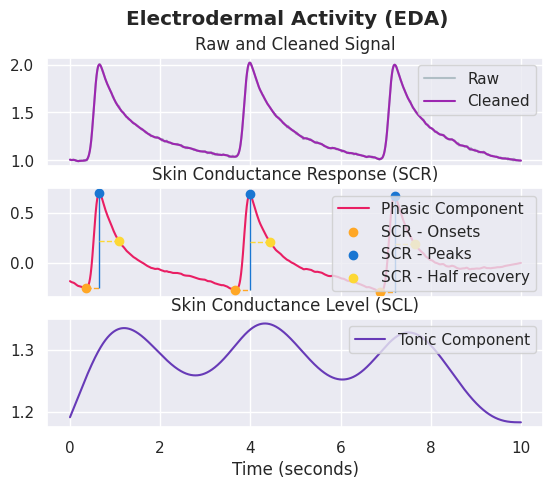

In [ ]:
#Example
#Neurokit example: https://github.com/neuropsychology/NeuroKit
eda = nk.eda_simulate(duration=10, scr_number=3)
# Process it
signals, info = nk.eda_process(eda, sampling_rate=250)

# Visualise the processing
p=nk.eda_plot(signals)

info

{'SCR_Onsets': array([  4,  23, 214]),
 'SCR_Peaks': array([ 16,  36, 268]),
 'SCR_Height': array([0.00990704, 0.02756241, 0.12453236]),
 'SCR_Amplitude': array([0.04437337, 0.02540013, 0.17109292]),
 'SCR_RiseTime': array([1.2, 1.3, 5.4]),
 'SCR_Recovery': array([nan, 60., nan]),
 'SCR_RecoveryTime': array([nan, 2.4, nan]),
 'sampling_rate': 10}

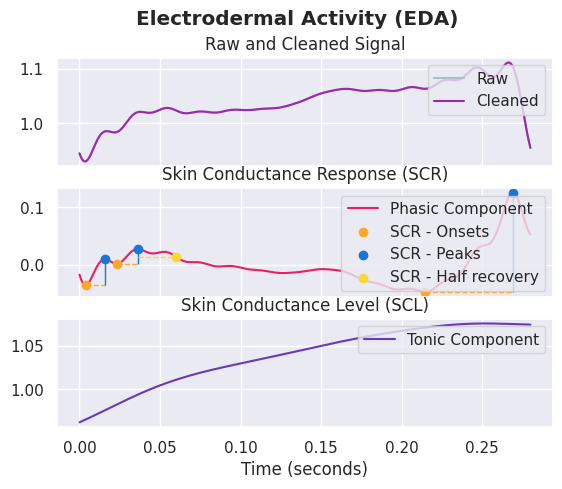

In [ ]:
#example with our data
my_eda = gsr_df_ma.iloc[10].dropna()
from scipy.signal import resample
#Neurokit required 10Hz sampling frequency. Here we upsample the signal
my_eda_resampled = resample(my_eda.values,len(my_eda.values)*10)
# Process it
signals, info = nk.eda_process(my_eda_resampled, sampling_rate=10)

# Visualise the processing
p=nk.eda_plot(signals)

info

In [ ]:
def extract_eda_features(df):

  feature_keys = ['SCR_Onsets', 'SCR_Peaks', 'SCR_Height', 'SCR_Amplitude', 'SCR_RiseTime', 'SCR_Recovery', 'SCR_RecoveryTime']

  #for each feature key we will caclulate min, max and mean values
  feature_names = []
  for f in feature_keys:
    feature_names.append('min_'+f)
    feature_names.append('max_'+f)
    feature_names.append('mean_'+f)


  #iterate through all 30-second segments
  features_arr = []
  for i in range(len(df)):
    my_eda = df.iloc[i].dropna()
    #Neurokit required 10Hz sampling frequency. Here we upsample the signal
    my_eda_resampled = resample(my_eda.values,len(my_eda.values)*10)
    # Process it
    signals, info = nk.eda_process(my_eda_resampled, sampling_rate=10)

    segment_features = []
    for k in feature_keys:
      #initial values are 0
      feature_min = 0
      feature_max = 0
      feature_mean = 0

      #drop Nan values
      values = info[k]
      values = values[~np.isnan(values)]
      if len(values)>0: #update feature-values if there is at least 1 detected value (e.g., at least one peak), else leave 0
        feature_min = np.min(values)
        feature_max = np.max(values)
        feature_mean = np.mean(values)
      segment_features.extend([feature_min,feature_max,feature_mean])
    features_arr.append(segment_features)
  return pd.DataFrame(features_arr,columns = feature_names)
gsr_expert_features = extract_eda_features(gsr_df_ma)

In [ ]:
gsr_expert_features

,min_SCR_Onsets,max_SCR_Onsets,mean_SCR_Onsets,min_SCR_Peaks,max_SCR_Peaks,mean_SCR_Peaks,min_SCR_Height,max_SCR_Height,mean_SCR_Height,min_SCR_Amplitude,...,mean_SCR_Amplitude,min_SCR_RiseTime,max_SCR_RiseTime,mean_SCR_RiseTime,min_SCR_Recovery,max_SCR_Recovery,mean_SCR_Recovery,min_SCR_RecoveryTime,max_SCR_RecoveryTime,mean_SCR_RecoveryTime
0,15.0,205.0,77.000000,4,214,70.400000,0.000279,0.007208,0.002652,0.000791,...,0.001746,0.9,1.1,1.000000,30.0,218.0,106.333333,0.4,0.6,0.533333
1,15.0,204.0,84.666667,4,214,71.750000,0.000453,0.005722,0.002732,0.000730,...,0.001392,0.9,1.0,0.966667,31.0,219.0,100.000000,0.5,0.6,0.566667
2,15.0,75.0,41.666667,4,197,67.250000,0.000084,0.002974,0.001313,0.000659,...,0.001890,0.9,12.2,4.666667,31.0,234.0,105.000000,0.6,3.7,1.666667
3,57.0,145.0,101.000000,4,196,101.666667,0.003175,0.003249,0.003213,0.001847,...,0.004400,4.8,5.1,4.950000,219.0,219.0,219.000000,2.3,2.3,2.300000
4,33.0,205.0,119.000000,5,214,87.333333,0.001811,0.004798,0.003629,0.000561,...,0.000819,0.9,1.0,0.950000,48.0,218.0,133.000000,0.4,0.5,0.450000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,24.0,205.0,114.000000,56,268,151.500000,0.014547,0.157305,0.066662,0.028287,...,0.124362,2.7,6.3,3.750000,83.0,179.0,129.000000,1.0,2.7,1.633333
745,21.0,225.0,107.666667,47,248,141.000000,0.003772,0.088753,0.042882,0.026295,...,0.053848,2.3,5.1,3.333333,64.0,265.0,158.666667,1.7,1.9,1.766667
746,132.0,132.0,132.000000,142,142,142.000000,0.094143,0.094143,0.094143,0.002849,...,0.002849,1.0,1.0,1.000000,147.0,147.0,147.000000,0.5,0.5,0.500000
747,38.0,217.0,135.333333,87,249,173.000000,-0.015819,0.122532,0.058122,0.132423,...,0.149228,3.2,4.9,3.766667,196.0,196.0,196.000000,1.3,1.3,1.300000


#### Heart Rate Variability

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,1060.020964,83.466138,36.602126,76.783897,17.685523,81.692637,NaN,NaN,64.451467,64.519189,...,1.689328,4.989563,1.255956,1.751363,1.328535,2.373092,1.923309,1.892273,3.50486,0.876727


<Figure size 1000x1000 with 0 Axes>

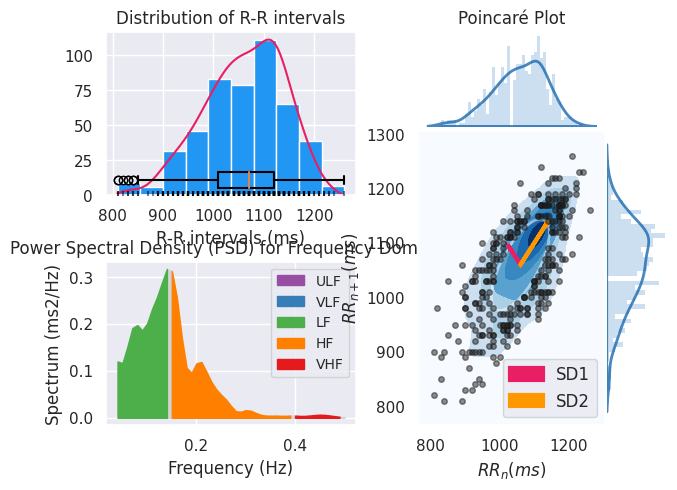

In [ ]:
#Example!!!
#neurokit example: https://github.com/neuropsychology/NeuroKit
data = nk.data("bio_resting_8min_100hz")

# Find peaks
peaks, info = nk.ecg_peaks(data["ECG"], sampling_rate=100)

# Compute HRV indices
ax = plt.figure(figsize=(10,10))
nk.hrv(peaks, sampling_rate=100, show=True)

In [ ]:
#example with our data
rr = rr_df_ma.iloc[1].dropna() #30-second rr intervals

#convert rr intervals to peaks array (input expected by neurokit)
peaks_rr = np.zeros(len(rr)*1000)
peaks_rr[0]=1
prev_peak = 0
for r in rr:
  peak_idx = prev_peak+int(r*1000)
  prev_peak = peak_idx
  peaks_rr[peak_idx]=1

#check if conversion was OK
print((rr*1000).astype(int).values) #convert to miliseconds
print(np.argwhere(peaks_rr==1)[:,0][1:] - np.argwhere(peaks_rr==1)[:,0][:-1] )

[582 584 578 569 560 556 558 564 567 569 569 571 573 577 577 575 567 560
 554 553 553 554 562 573 584 586 582 571]
[582 584 578 569 560 556 558 564 567 569 569 571 573 577 577 575 567 560
 554 553 553 554 562 573 584 586 582 571]


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,568.857143,10.287404,NaN,NaN,NaN,NaN,NaN,NaN,5.763872,5.858979,...,1.011601,3.99468,1.029546,0.0,0.0,0.0,1.799924,1.558538,1.780621,1.030147


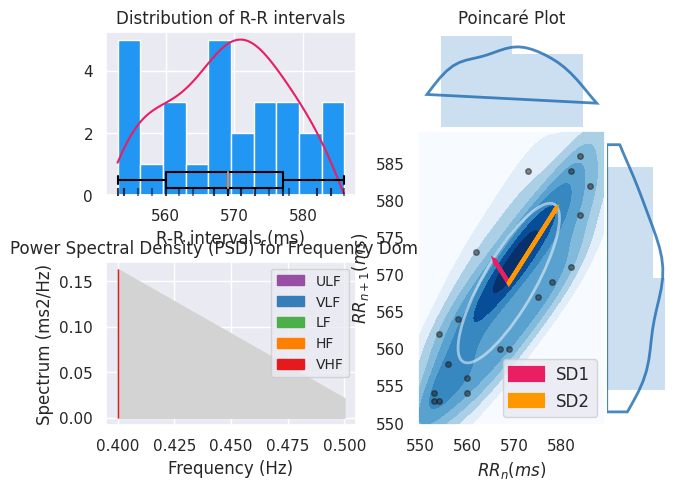

In [ ]:
#perform HRV analysis over our data
example_df = nk.hrv(peaks_rr, sampling_rate=1000, show=True)
example_df

In [ ]:
example_df.columns

Index(['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2',
       'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD',
       'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN',
       'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50',
       'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF',
       'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF',
       'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2',
       'HRV_S', 'HRV_CSI', 'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP',
       'HRV_IALS', 'HRV_PSS', 'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI',
       'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d',
       'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a', 'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd',
       'HRV_SDNNa', 'HRV_DFA_alpha1', 'HRV_MFDFA_alpha1_Width',
       'HRV_MFDFA_alpha1_Peak', 'HRV_MFDFA_alpha1_Mean',
       'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Delta',
     

In [ ]:
def extract_HRV_features(df):
  feature_names = ['HRV_RMSSD', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_SDSD', 'HRV_CVNN',
       'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN',
       'HRV_pNN50', 'HRV_pNN20', 'HRV_TINN', 'HRV_HTI', 'HRV_ULF', 'HRV_VLF',
       'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn',
       'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HRV_CSI',
       'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP', 'HRV_IALS', 'HRV_PSS',
       'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI', 'HRV_PI', 'HRV_C1d', 'HRV_C1a',
       'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d', 'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a',
       'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd', 'HRV_SDNNa', 'HRV_ApEn', 'HRV_SampEn',
       'HRV_MSE', 'HRV_CMSE', 'HRV_RCMSE', 'HRV_DFA', 'HRV_CorrDim']

  features_arr = []
  for i in range(len(df)):

    try: #to avoid exceptions
      rr = df.iloc[i].dropna() #30-second rr intervals

      #convert rr intervals to peaks array (input expected by neurokit)
      peaks_rr = np.zeros((len(rr)+1)*1000)
      peaks_rr[0]=1
      prev_peak = 0
      for r in rr:
        peak_idx = prev_peak+int(r*1000)
        prev_peak = peak_idx
        peaks_rr[peak_idx]=1

      segment_features = nk.hrv(peaks_rr, sampling_rate=1000, show=False)
      features_arr.append(segment_features)
    except Exception as e: #when exception happens, fill-in with zeros
      values=np.zeros(len(feature_names))
      segment_features = pd.DataFrame([values],columns=feature_names)
      features_arr.append(segment_features)


  return pd.concat(features_arr)

hrv_features = extract_HRV_features(rr_df_ma)

In [ ]:
#check for NaN values
hrv_features.isnull().sum()

,0
HRV_MeanNN,0
HRV_SDNN,0
HRV_SDANN1,749
HRV_SDNNI1,749
HRV_SDANN2,749
...,...
HRV_MSE,715
HRV_CMSE,715
HRV_RCMSE,715
HRV_DFA,715


In [ ]:
hrv_features.isnull()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_MSE,HRV_CMSE,HRV_RCMSE,HRV_DFA,HRV_CorrDim
0,False,False,True,True,True,True,True,True,False,False,...,False,False,False,False,False,True,True,True,True,True
0,False,False,True,True,True,True,True,True,False,False,...,False,False,False,False,False,True,True,True,True,True
0,False,False,True,True,True,True,True,True,False,False,...,False,False,False,False,False,True,True,True,True,True
0,False,False,True,True,True,True,True,True,False,False,...,False,False,False,False,False,True,True,True,True,True
0,False,False,True,True,True,True,True,True,False,False,...,True,False,False,False,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,False,False,True,True,True,True,True,True,False,False,...,True,False,False,False,False,True,True,True,True,True
0,False,False,True,True,True,True,True,True,False,False,...,False,False,False,False,False,True,True,True,True,True
0,False,False,True,True,True,True,True,True,False,False,...,False,False,False,False,False,True,True,True,True,True
0,False,False,True,True,True,True,True,True,False,False,...,False,False,False,False,False,True,True,True,True,True


In [ ]:
#remove Nan values
#keep only features with no Nan values
hrv_features.replace([np.inf, -np.inf], np.nan, inplace=True)

good_features = (hrv_features.isnull().sum()==0)

hrv_features = hrv_features[hrv_features.columns[good_features]]

In [ ]:
hrv_features.shape

(749, 45)

In [ ]:
hrv_features.isnull().sum()

,0
HRV_MeanNN,0
HRV_SDNN,0
HRV_RMSSD,0
HRV_SDSD,0
HRV_CVNN,0
HRV_CVSD,0
HRV_MedianNN,0
HRV_MadNN,0
HRV_MCVNN,0
HRV_IQRNN,0


### Summary

In [ ]:
hrv_features = hrv_features.reset_index().drop('index',axis=1)
all_features = pd.concat([stat_feat_all,gsr_expert_features,hrv_features],axis=1)

In [ ]:
hrv_features

,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,...,HRV_SD1a,HRV_C2d,HRV_C2a,HRV_SD2d,HRV_SD2a,HRV_Cd,HRV_Ca,HRV_SDNNd,HRV_SDNNa,HRV_ApEn
0,609.107143,15.779357,9.455549,9.611692,0.025906,0.015524,609.5,16.3086,0.026757,21.25,...,4.283241,0.445083,0.554917,14.366192,16.041124,0.459619,0.540381,10.827382,11.740184,0.097738
1,568.857143,10.287404,5.763872,5.858979,0.018084,0.010132,569.0,12.6021,0.022148,17.00,...,3.116334,0.523007,0.476993,10.113462,9.658334,0.516036,0.483964,7.410148,7.176174,0.245888
2,589.071429,75.959506,26.543465,27.026947,0.128948,0.045060,554.5,37.0650,0.066844,90.75,...,11.013977,0.505047,0.494953,76.266491,75.500462,0.510076,0.489924,55.050417,53.951958,0.148689
3,606.214286,71.533135,48.271992,49.101093,0.118000,0.079629,607.0,66.7170,0.109913,88.75,...,21.017850,0.467965,0.532035,65.701957,70.055366,0.487321,0.512679,50.422718,51.718006,0.114318
4,700.607143,110.694220,69.311695,70.599266,0.157998,0.098931,715.5,117.1254,0.163697,162.00,...,34.285005,0.568252,0.431748,113.667377,99.078695,0.564349,0.435651,84.377880,74.135179,0.218981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,801.214286,53.982409,46.186017,46.892251,0.067376,0.057645,799.5,61.5279,0.076958,69.75,...,20.065278,0.528013,0.471987,48.734488,46.076468,0.549448,0.450552,39.243032,35.536293,0.197671
745,825.250000,55.731250,29.201725,29.746412,0.067533,0.035385,827.0,44.4780,0.053782,64.00,...,16.710775,0.458631,0.541369,52.433838,56.967430,0.452487,0.547513,38.162983,41.979388,0.236229
746,800.857143,82.517210,43.797091,44.330859,0.103036,0.054688,807.0,103.7820,0.128602,123.00,...,22.343042,0.371495,0.628505,67.835688,88.234102,0.380967,0.619033,50.489849,64.360191,0.155007
747,702.071429,85.625770,41.234649,42.020074,0.121962,0.058733,717.5,71.9061,0.100218,94.25,...,21.663511,0.594556,0.405444,92.238258,76.169335,0.587226,0.412774,66.788602,55.995872,0.228118


In [ ]:
print("Statistical features",stat_feat_all.shape,)
print('GSR expert features',gsr_expert_features.shape)
print('HRV features',hrv_features.shape)
print('Merged features',all_features.shape)
print('Nan values',all_features.isnull().sum().sum())

Statistical features (749, 40)
GSR expert features (749, 21)
HRV features (749, 45)
Merged features (749, 106)
Nan values 0


In [ ]:
all_features.shape,label_df.shape

((749, 106), (749, 21))

In [ ]:
all_features.to_csv('/content/drive/MyDrive/CogLoad-1Hz/features.csv')
label_df.to_csv('/content/drive/MyDrive/CogLoad-1Hz/labels.csv')

## Model learning

### Train/test split

In [ ]:
test_ids = ['3caqi','6frz4','bd47a','f1gjp','iz3x1']

train_ids = ['1mpau', '2nxs5', '5gpsc', '7swyk', '8a1ep', 'b7mrd',
       'c24ur', 'dkhty', 'e4gay', 'ef5rq', 'f3j25', 'hpbxa',
       'ibvx8', 'iz2ps', 'rc1in', 'tn4vl', 'wjxci', 'yljm5']

X_train = []
y_train = []
X_test = []
y_test = []

for user in label_df.user_id.unique():
  if user in train_ids:
    X_train.append(all_features[label_df.user_id==user])
    y = label_df.loc[label_df.user_id==user,'level'].values #labels
    #convert labels (rest,0,1,2) to binary (rest vs task)
    y[y=='rest'] = -1
    y = y.astype(int)+1
    y[y>0]=1
    y_train.extend(y)
  else:
    X_test.append(all_features[label_df.user_id==user])
    y = label_df.loc[label_df.user_id==user,'level'].values  #labels
    #convert labels (rest,0,1,2) to binary (rest vs task)
    y[y=='rest'] = -1
    y = y.astype(int)+1
    y[y>0]=1
    y_test.extend(y)


X_train = pd.concat(X_train)
y_train = np.array(y_train)
X_test = pd.concat(X_test)
y_test = np.array(y_test)
print('Train data:',X_train.shape,y_train.shape)
print('Test data:',X_test.shape,y_test.shape)

Train data: (575, 106) (575,)
Test data: (174, 106) (174,)


### Distribution visualization

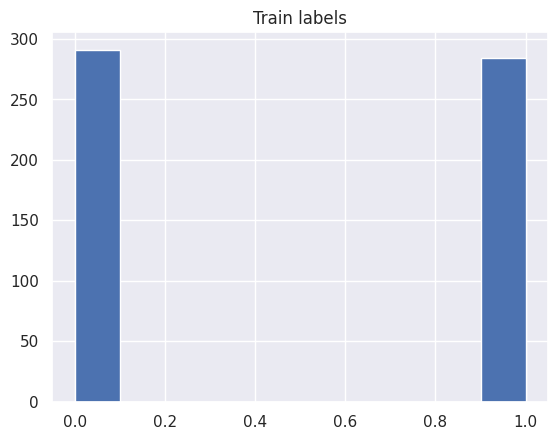

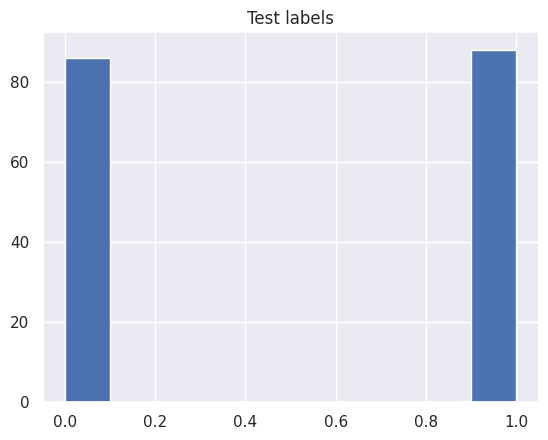

In [ ]:
plt.hist(y_train)
plt.title('Train labels')
plt.show()

plt.hist(y_test)
plt.title('Test labels')
plt.show()

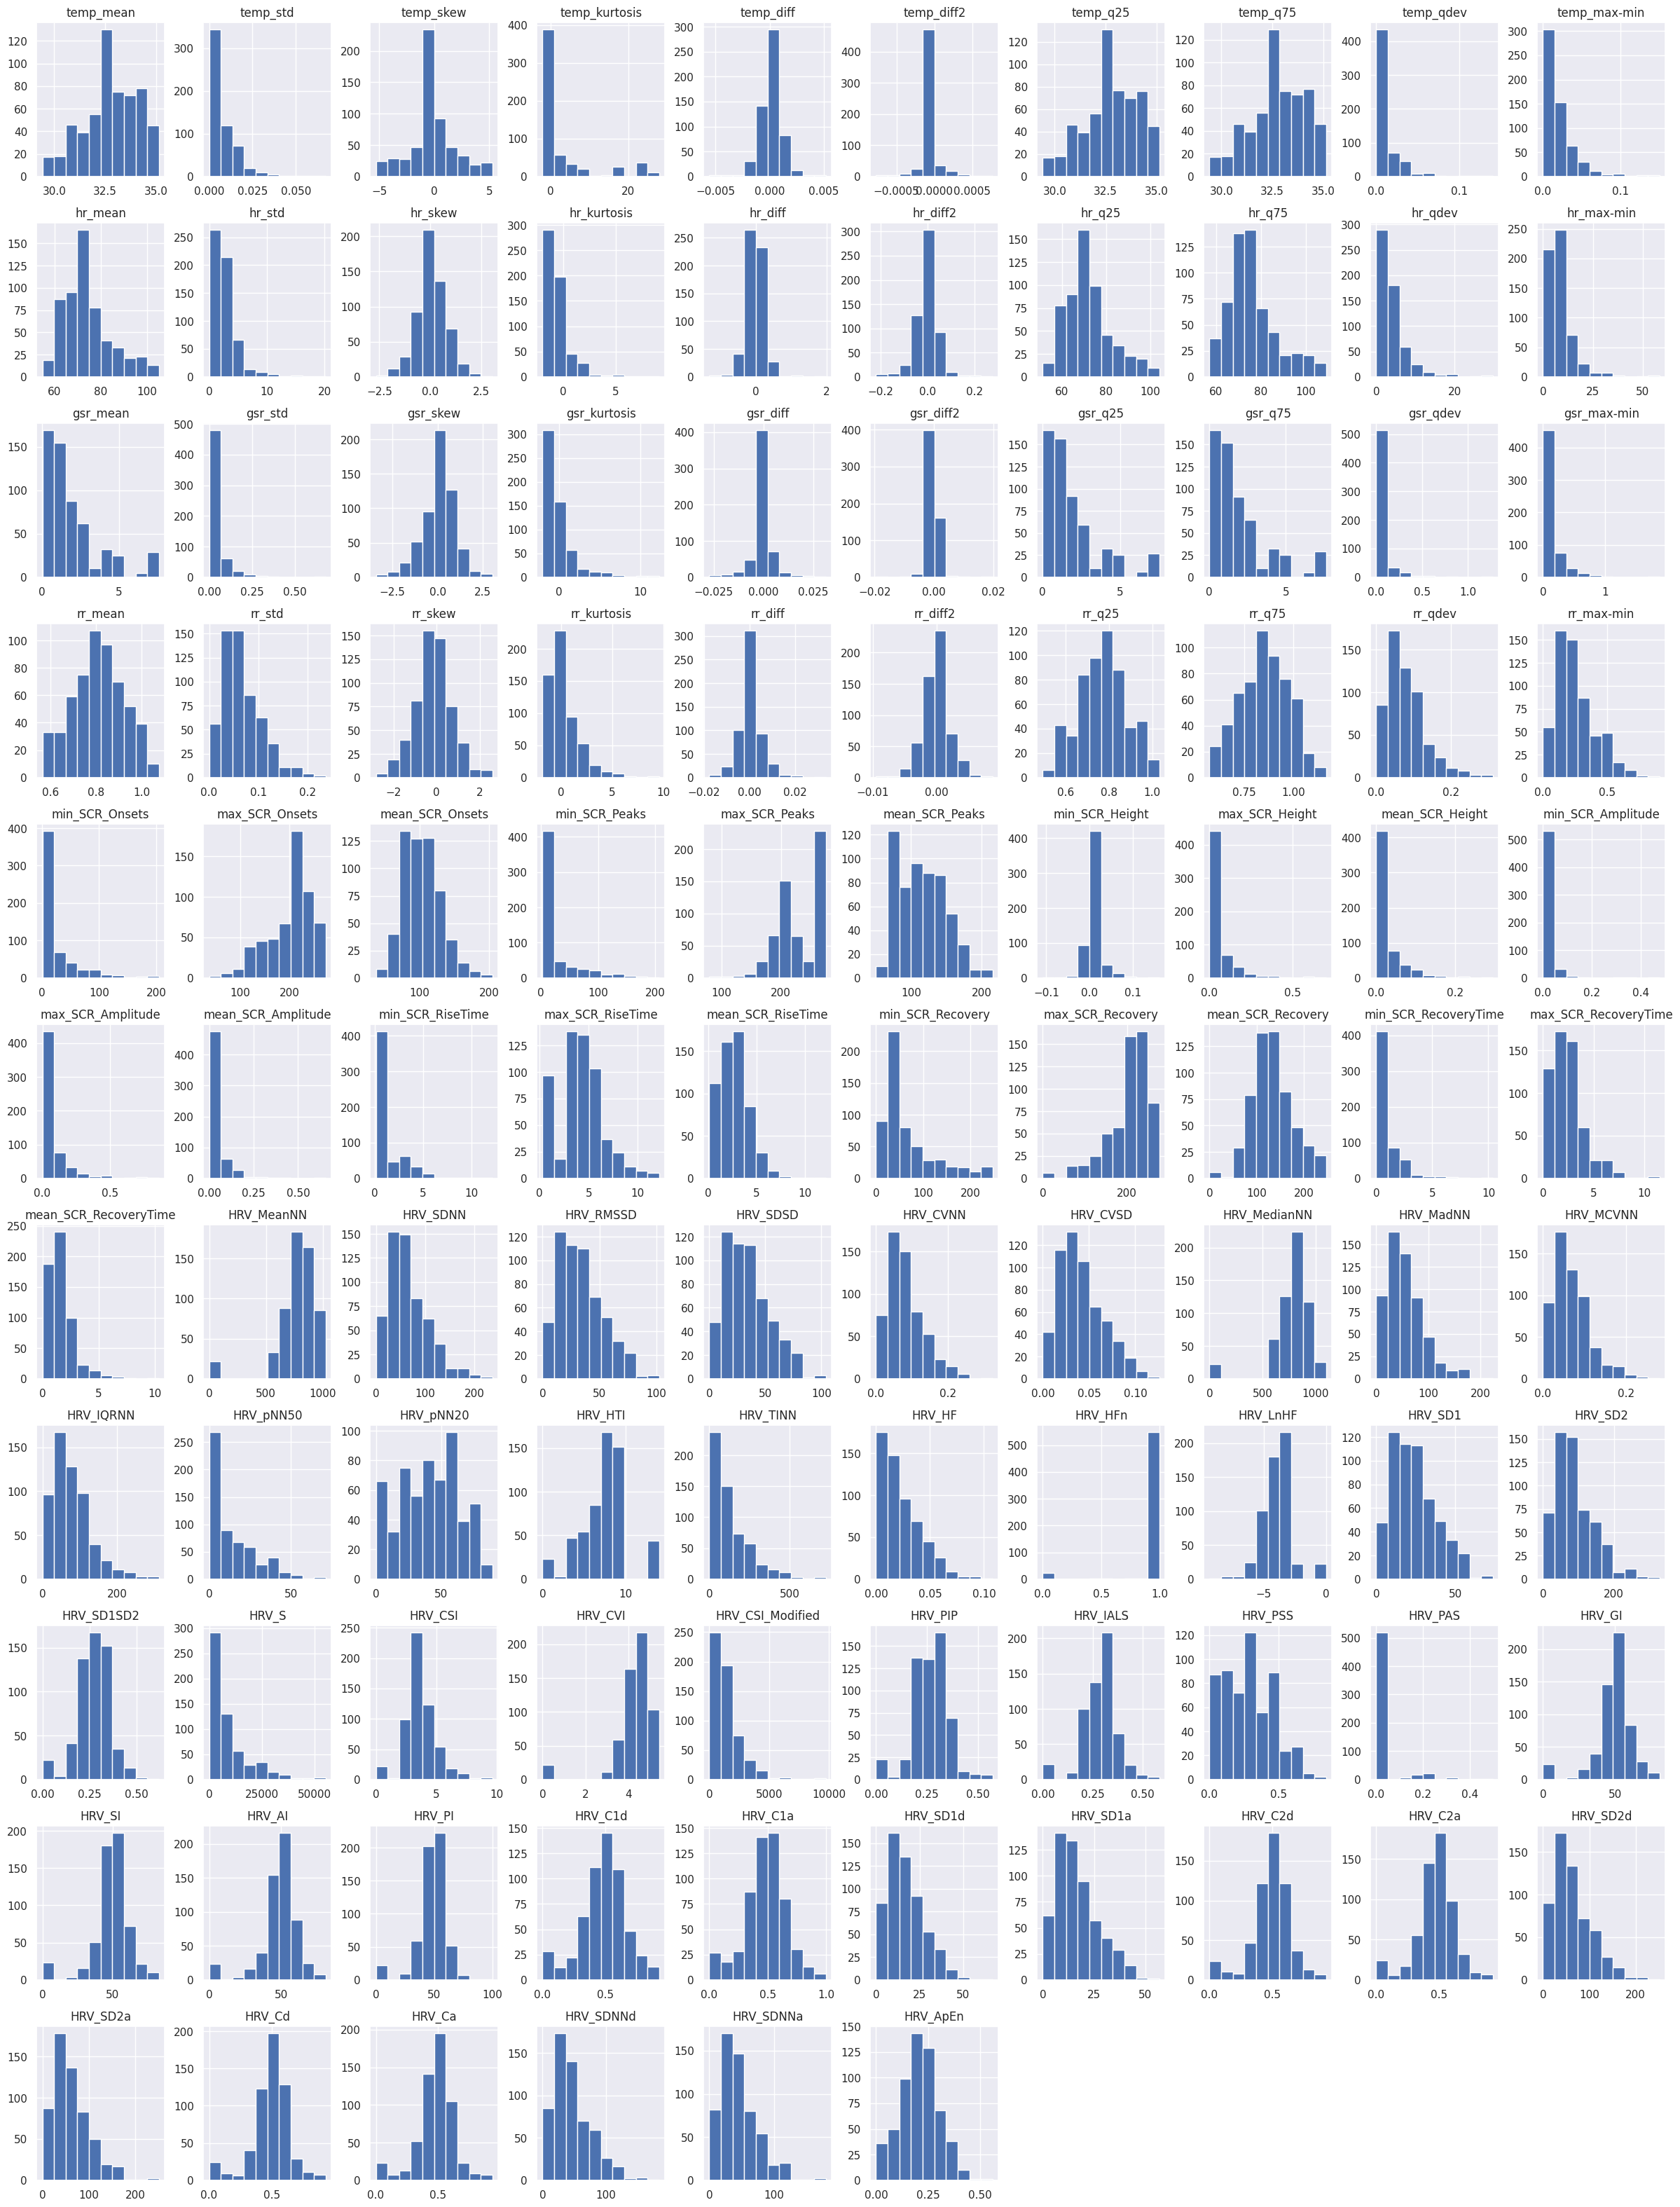

In [ ]:
#plot distribution of training features
X_train.hist(figsize=(30,40))
plt.show()

### Simple ML

In [ ]:
#Decision tree
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train,y_train) #train the classifier
pred = clf.predict(X_test)
print('Report for a Decision tree')
print(classification_report(y_test,pred))

print()
#Majority classifier
dummy = DummyClassifier()
dummy.fit(X_train,y_train) #train the classifier
pred = dummy.predict(X_test)
print('Report for a Dummy classifier')
print(classification_report(y_test,pred))

Report for a Decision tree
              precision    recall  f1-score   support

           0       0.65      0.53      0.59        86
           1       0.61      0.72      0.66        88

    accuracy                           0.63       174
   macro avg       0.63      0.63      0.62       174
weighted avg       0.63      0.63      0.62       174


Report for a Dummy classifier
              precision    recall  f1-score   support

           0       0.49      1.00      0.66        86
           1       0.00      0.00      0.00        88

    accuracy                           0.49       174
   macro avg       0.25      0.50      0.33       174
weighted avg       0.24      0.49      0.33       174



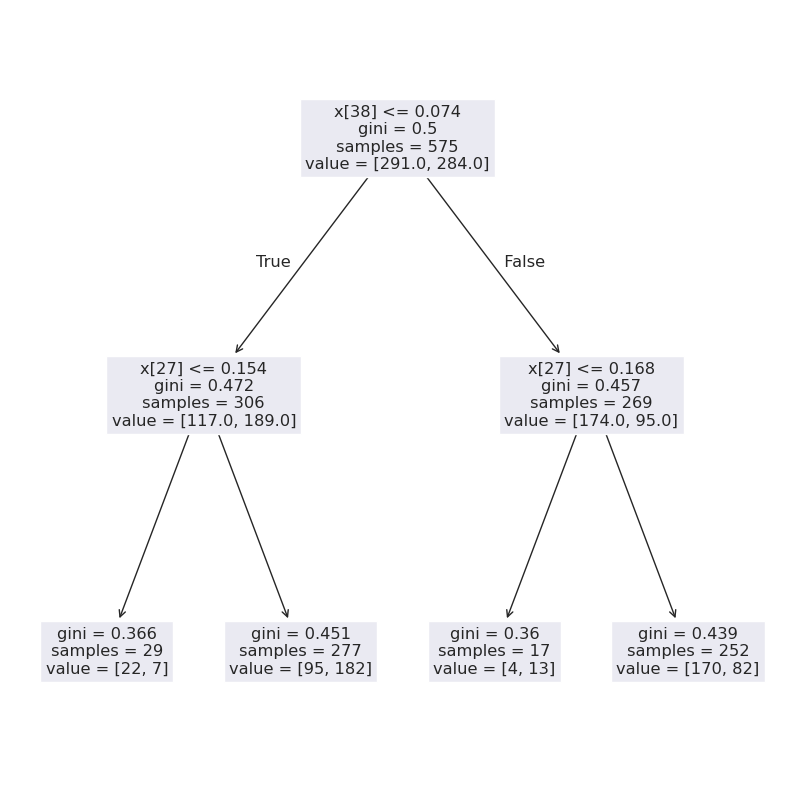

Index(['rr_qdev', 'HRV_SD2', 'gsr_max-min'], dtype='object')

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
p = plot_tree(clf)
plt.show()

selected_features = [38,79,29] #indices of selected features in the trees
X_train.columns[selected_features]

### Feature selection

Perform feature selection using feature ranking with recursive feature elimination. In addition, use leave-onse-subject-out evlauation (on the training data) to score differet feature-subsets.

More info on feature ranking with recursive feature elimination [here.](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html)

In [ ]:
gk = GroupKFold(n_splits=len(np.unique(train_ids)))
splits = gk.get_n_splits(X_train, y_train, train_ids) #generate folds to evaluate the models using leave-one-subject-out
estimator = XGBClassifier(n_jobs=-1)
fs_clf = RFECV(estimator=estimator, #which estimator to use
              step=1, #how many features to be removed at each iteration
              cv=splits,#use pre-defined splits for evaluation (LOSO)
              scoring='accuracy',
              min_features_to_select=1,
              n_jobs=-1)

fs_clf.fit(X_train, y_train)#perform feature selection. Depending on the size of the data and the estimator, this may last for a while
selected_features = X_train.columns[fs_clf.ranking_==1]

pred = fs_clf.predict(X_test)
print('Report for XGBClassifier with feature selection')
print(classification_report(y_test,pred))

print("Selected features:", selected_features)

Report for XGBClassifier with feature selection
              precision    recall  f1-score   support

           0       0.67      0.66      0.67        86
           1       0.67      0.68      0.68        88

    accuracy                           0.67       174
   macro avg       0.67      0.67      0.67       174
weighted avg       0.67      0.67      0.67       174

Selected features: Index(['temp_mean', 'temp_std', 'temp_skew', 'temp_kurtosis', 'temp_diff',
       'temp_max-min', 'hr_std', 'hr_skew', 'hr_kurtosis', 'hr_diff',
       'hr_diff2', 'hr_q25', 'hr_qdev', 'gsr_mean', 'gsr_kurtosis', 'gsr_diff',
       'gsr_diff2', 'gsr_q25', 'gsr_q75', 'gsr_max-min', 'rr_std', 'rr_skew',
       'rr_kurtosis', 'rr_diff2', 'rr_q25', 'rr_qdev', 'min_SCR_Onsets',
       'mean_SCR_Onsets', 'min_SCR_Peaks', 'max_SCR_Peaks', 'min_SCR_Height',
       'max_SCR_Height', 'mean_SCR_Height', 'min_SCR_Amplitude',
       'min_SCR_RiseTime', 'max_SCR_RiseTime', 'min_SCR_Recovery',
       'max_SCR_Reco

### Hyper-parameter tuning

In [ ]:
#selected_features = ['hr_q25', 'gsr_mean', 'gsr_q75', 'gsr_max-min', 'rr_qdev',
#       'min_SCR_Height', 'min_SCR_Amplitude', 'min_SCR_Recovery', 'HRV_MeanNN',
#       'HRV_CVNN', 'HRV_CVSD', 'HRV_MCVNN', 'HRV_AI', 'HRV_PI', 'HRV_C1d',
#       'HRV_SD1a', 'HRV_ApEn']

selected_features = ['temp_mean', 'temp_std', 'temp_skew', 'temp_kurtosis', 'temp_diff',
       'temp_qdev', 'hr_mean', 'hr_std', 'hr_skew', 'hr_kurtosis', 'hr_diff',
       'hr_diff2', 'hr_q25', 'hr_qdev', 'hr_max-min', 'gsr_mean', 'gsr_std',
       'gsr_skew', 'gsr_kurtosis', 'gsr_diff', 'gsr_diff2', 'gsr_q25',
       'gsr_q75', 'gsr_qdev', 'gsr_max-min', 'rr_mean', 'rr_skew',
       'rr_kurtosis', 'rr_diff', 'rr_diff2', 'rr_q25', 'rr_q75', 'rr_qdev',
       'min_SCR_Onsets', 'max_SCR_Onsets', 'mean_SCR_Onsets', 'min_SCR_Peaks',
       'max_SCR_Peaks', 'mean_SCR_Peaks', 'min_SCR_Height', 'max_SCR_Height',
       'mean_SCR_Height', 'min_SCR_Amplitude', 'max_SCR_Amplitude',
       'mean_SCR_Amplitude', 'min_SCR_RiseTime', 'max_SCR_RiseTime',
       'max_SCR_Recovery', 'mean_SCR_Recovery', 'max_SCR_RecoveryTime',
       'mean_SCR_RecoveryTime', 'HRV_MeanNN', 'HRV_SDSD', 'HRV_CVNN',
       'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_pNN20',
       'HRV_HTI', 'HRV_TINN', 'HRV_HF', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1SD2',
       'HRV_CSI_Modified', 'HRV_IALS', 'HRV_PSS', 'HRV_GI', 'HRV_PI',
       'HRV_C1d', 'HRV_SD1a', 'HRV_C2d', 'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a',
       'HRV_SDNNd', 'HRV_ApEn']

clf_xgb = XGBClassifier(n_jobs=-1)
parallel_jobs=-1
paramsXGB = {
        'n_estimators' : [10,100],
        'min_child_weight': [1, 3, 5],
        'learning_rate':[0.05,0.1,0.2],
        'subsample': [0.5,0.75,1.0],
        'max_depth': [4,6,8]
        }
gridXGB = GridSearchCV(estimator=clf_xgb,
                             param_grid=paramsXGB,
                             cv=splits,
                             n_jobs=parallel_jobs)
gridXGB.fit(X_train[selected_features], y_train)#perform hyperparameter tuning. Depending on the size of the data and the estimator, this may last for a w

pred = gridXGB.predict(X_test[selected_features])
print('Report for XGBClassifier with hyperparameter tuning')
print(classification_report(y_test,pred))
print()
print('Hyperparameters:', gridXGB.best_estimator_)

Report for XGBClassifier with hyperparameter tuning
              precision    recall  f1-score   support

           0       0.60      0.66      0.63        86
           1       0.63      0.57      0.60        88

    accuracy                           0.61       174
   macro avg       0.62      0.62      0.61       174
weighted avg       0.62      0.61      0.61       174


Hyperparameters: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=1, missing=nan, monotone

In [ ]:
XGBClassifier.feature_importances_

### Part 2.3: Deep Learning

https://colab.research.google.com/drive/1Y6gstz3ybo8efObCaEmg5KsMbGEOfzoe?usp=sharing#scrollTo=Szy2EGZ30P6w

<img src=https://images.deepai.org/converted-papers/1911.08030/img/my/archc.png height =350>

Image from: Girma, A., Yan, X., & Homaifar, A. (2019, November). Driver identification based on vehicle telematics data using lstm-recurrent neural network. In 2019 IEEE 31st International Conference on Tools with Artificial Intelligence (ICTAI) (pp. 894-902). IEEE.

In [ ]:
#to access files and folders
import os
#data analysis and manipulation library
import pandas as pd
#math operations for multi-dimensional arrays and matrices
import numpy as np
#visualziation libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set() #use a specific color theme

## Data reading
We segmented the data into 30-second windows in Part 1 of this tutorial. Now, we will read the segmented data

In [ ]:
#read the data
data_folder_path = '/content/drive/MyDrive/CogLoad-1Hz/'
print('Reading data')
label_df = pd.read_csv(data_folder_path+'segments_labels.csv',index_col=0)
temp_df= pd.read_csv(data_folder_path+'segments_temperature.csv',index_col=0)
hr_df= pd.read_csv(data_folder_path+'segments_heartrate.csv',index_col=0)
gsr_df = pd.read_csv(data_folder_path+'segments_gsr.csv',index_col=0)
rr_df= pd.read_csv(data_folder_path+'segments_rr.csv',index_col=0)
print('Done')

#check 30-second segments
print("Data shapes:")
print('Labels',label_df.shape)
print('Temperature',temp_df.shape)
print('Heartrate',hr_df.shape)
print('GSR',gsr_df.shape)
print('RR',rr_df.shape)

Reading data
Done
Data shapes:
Labels (749, 21)
Temperature (749, 30)
Heartrate (749, 30)
GSR (749, 30)
RR (749, 30)


## Normalize data

In [ ]:
#min-max normalization
temp_df_norm = (temp_df-temp_df.min())/(temp_df.max()-temp_df.min())
hr_df_norm = (hr_df-hr_df.min())/(hr_df.max()-hr_df.min())
gsr_df_norm = (gsr_df-gsr_df.min())/(gsr_df.max()-gsr_df.min())
rr_df_norm = (rr_df-rr_df.min())/(rr_df.max()-rr_df.min())

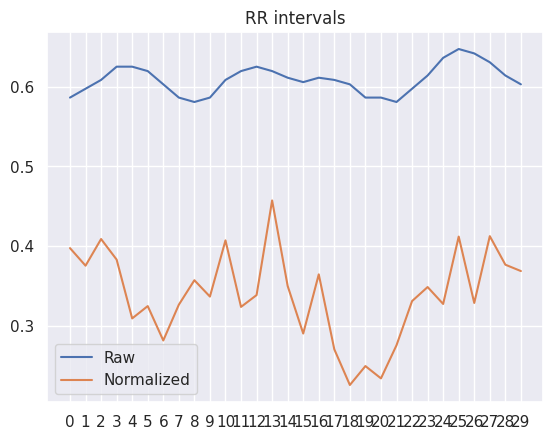

In [ ]:
#plot first segment from each data type (raw and fitlered values)
plt.plot(rr_df.iloc[0],label='Raw')
plt.plot(rr_df_norm.iloc[0],label='Normalized')
plt.title('RR intervals')
plt.legend()
plt.show()
print()

## Prepare data for DL and Train/Test split

In [ ]:
#reshape data for DL
all_data = np.array([temp_df_norm.values,hr_df_norm.values,gsr_df_norm.values,rr_df_norm.values]).transpose(1,2,0)
all_data.shape

(749, 30, 4)

In [ ]:
test_ids = ['3caqi','6frz4','bd47a','f1gjp','iz3x1']
train_ids = ['1mpau', '2nxs5', '5gpsc', '7swyk', '8a1ep', 'b7mrd',
       'c24ur', 'dkhty', 'e4gay', 'ef5rq', 'f3j25', 'hpbxa',
       'ibvx8', 'iz2ps', 'rc1in', 'tn4vl', 'wjxci', 'yljm5']

X_train = []
y_train = []
X_test = []
y_test = []

for user in label_df.user_id.unique():
  if user in train_ids:
    X_train.append(all_data[label_df.user_id==user])
    y = label_df.loc[label_df.user_id==user,'level'].values #labels
    #convert labels (rest,0,1,2) to binary (rest vs task)
    y[y=='rest'] = -1
    y = y.astype(int)+1
    y[y>0]=1
    y_train.extend(y)
  else:
    X_test.append(all_data[label_df.user_id==user])
    y = label_df.loc[label_df.user_id==user,'level'].values  #labels
    #convert labels (rest,0,1,2) to binary (rest vs task)
    y[y=='rest'] = -1
    y = y.astype(int)+1
    y[y>0]=1
    y_test.extend(y)


X_train = np.concatenate(X_train)
y_train = np.array(y_train)
X_test = np.concatenate(X_test)
y_test = np.array(y_test)
print('Train data:',X_train.shape,y_train.shape)
print('Test data:',X_test.shape,y_test.shape)

Train data: (575, 30, 4) (575,)
Test data: (174, 30, 4) (174,)


In [ ]:
from collections import Counter
counter = Counter(y_train)
print(f"Class Distribution in Training Set: {counter}")

Class Distribution in Training Set: Counter({0: 291, 1: 284})


###Define DL model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, MaxPooling1D, Flatten

# Reshape the data for non-sequential models like Random Forest and XGBoost
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Train Random Forest
# Train Random Forest with optimized hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=500,         # Updated to 500
    max_depth=20,             # Updated to 10
    max_features='sqrt',      # Updated to 'sqrt'
    min_samples_leaf=4,       # Updated to 4
    min_samples_split=2,      # Updated to 2
    random_state=42           # Keep random state for reproducibility
)

# Fit the model
rf_model.fit(X_train_flat, y_train)

# Train XGBoost
xgb_model = XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=20, random_state=42)
xgb_model.fit(X_train_flat, y_train)

# Train LSTM Model
#We can also increase the number of epochs to 100
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(LSTM(50, return_sequences=False))
lstm_model.add(Dense(1, activation='sigmoid'))
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=2)

# Train CNN Model
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
cnn_model.add(MaxPooling1D(pool_size=3))
cnn_model.add(Flatten())
cnn_model.add(Dense(50, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=2)




Epoch 1/100
36/36 - 3s - 90ms/step - accuracy: 0.4957 - loss: 0.6963 - val_accuracy: 0.4655 - val_loss: 0.6944
Epoch 2/100
36/36 - 0s - 12ms/step - accuracy: 0.4870 - loss: 0.6944 - val_accuracy: 0.5057 - val_loss: 0.6938
Epoch 3/100
36/36 - 0s - 12ms/step - accuracy: 0.4887 - loss: 0.6944 - val_accuracy: 0.4828 - val_loss: 0.6954
Epoch 4/100
36/36 - 0s - 14ms/step - accuracy: 0.4678 - loss: 0.6935 - val_accuracy: 0.4770 - val_loss: 0.6944
Epoch 5/100
36/36 - 0s - 7ms/step - accuracy: 0.5183 - loss: 0.6940 - val_accuracy: 0.4943 - val_loss: 0.6954
Epoch 6/100
36/36 - 0s - 8ms/step - accuracy: 0.5130 - loss: 0.6938 - val_accuracy: 0.4483 - val_loss: 0.6956
Epoch 7/100
36/36 - 0s - 8ms/step - accuracy: 0.4974 - loss: 0.6937 - val_accuracy: 0.4885 - val_loss: 0.6946
Epoch 8/100
36/36 - 0s - 8ms/step - accuracy: 0.5043 - loss: 0.6938 - val_accuracy: 0.4598 - val_loss: 0.6947
Epoch 9/100
36/36 - 0s - 7ms/step - accuracy: 0.5009 - loss: 0.6929 - val_accuracy: 0.4368 - val_loss: 0.6957
Epoch 

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Random Forest
rf_preds = rf_model.predict(X_test_flat)
print("Random Forest Classification Report")
print(classification_report(y_test, rf_preds))
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")

# XGBoost
xgb_preds = xgb_model.predict(X_test_flat)
print("XGBoost Classification Report")
print(classification_report(y_test, xgb_preds))
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")

# LSTM
lstm_preds = (lstm_model.predict(X_test) >= 0.5).astype(int).flatten()
print("LSTM Classification Report")
print(classification_report(y_test, lstm_preds))
print(f"Accuracy: {accuracy_score(y_test, lstm_preds):.4f}")

# CNN
cnn_preds = (cnn_model.predict(X_test) >= 0.5).astype(int).flatten()
print("CNN Classification Report")
print(classification_report(y_test, cnn_preds))
print(f"Accuracy: {accuracy_score(y_test, cnn_preds):.4f}")

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.55      0.63      0.58        86
           1       0.57      0.49      0.53        88

    accuracy                           0.56       174
   macro avg       0.56      0.56      0.56       174
weighted avg       0.56      0.56      0.56       174

Accuracy: 0.5575
XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.61      0.59      0.60        86
           1       0.62      0.64      0.63        88

    accuracy                           0.61       174
   macro avg       0.61      0.61      0.61       174
weighted avg       0.61      0.61      0.61       174

Accuracy: 0.6149
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
LSTM Classification Report
              precision    recall  f1-score   support

           0       0.55      0.49      0.52        86
           1       0.55      0.61      0.58        88

    accuracy     

Hyperparameter Tuning for Optimal Accuracy

In [ ]:
# Generate predictions on the test set from each model
rf_preds = rf_model.predict_proba(X_test_flat)[:, 1]  # Probability for the positive class
xgb_preds = xgb_model.predict_proba(X_test_flat)[:, 1]
lstm_preds = lstm_model.predict(X_test).flatten()  # Flatten to make it 1D
cnn_preds = cnn_model.predict(X_test).flatten()  # Flatten to make it 1D

# Stack predictions into a single matrix (new feature set)
stacked_predictions = np.column_stack((rf_preds, xgb_preds, lstm_preds, cnn_preds))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


**Train the Meta-Model**

With the predictions from the CNN model included, you can proceed with training the meta-model as before:



In [ ]:
from sklearn.linear_model import LogisticRegression

# Train a meta-model (e.g., Logistic Regression) on the stacked predictions
meta_model = LogisticRegression(random_state=42)
meta_model.fit(stacked_predictions, y_test)

# Make final predictions on the test set
final_predictions = meta_model.predict(stacked_predictions)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate the performance of the stacked model
print("Report for Stacked Model")
print(classification_report(y_test, final_predictions))
print(f"Accuracy: {accuracy_score(y_test, final_predictions)}")

Report for Stacked Model
              precision    recall  f1-score   support

           0       0.64      0.58      0.61        86
           1       0.62      0.68      0.65        88

    accuracy                           0.63       174
   macro avg       0.63      0.63      0.63       174
weighted avg       0.63      0.63      0.63       174

Accuracy: 0.632183908045977


**Next Steps:**

**Fine-tuning:**Further hyperparameter tuning of the individual models within the stack to improve performance even more.

**Data Augmentation:** Exploring data augmentation or feature engineering to potentially boost model performance further.

**Model Interpretability:** Analyzing feature importance or using model interpretation techniques to understand which features are contributing most to the predictions.
